In [ ]:
# ======================================
# CELL 1 — Drive Mount করো
# ======================================
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive connected!")

Mounted at /content/drive
✅ Google Drive connected!


In [ ]:
# ======================================
# CELL 2 — সব Install করো
# ======================================
!pip install transformers datasets sentence-transformers faiss-cpu bert-score scikit-learn -q
print("✅ Install শেষ!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.3 MB/s eta 0:00:00
✅ Install শেষ!


In [ ]:
# ======================================
# CELL 3 — সব Import + Dataset লোড
# ======================================
import torch
import pandas as pd
import json
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ✅ তোর নিজের uploaded file থেকে Sarcasm Dataset
from google.colab import files
print("📁 Sarcasm_Headlines_Dataset_v2.json upload করো:")
uploaded = files.upload()

data = []
with open("Sarcasm_Headlines_Dataset_v2.json", "r") as f:
    for line in f:
        data.append(json.loads(line))
df_sarcasm = pd.DataFrame(data)
print(f"✅ Sarcasm (তোর file) — {len(df_sarcasm)} rows")

# SemEval Irony Dataset
dataset_irony = load_dataset("cardiffnlp/tweet_eval", "irony")
df_irony_train = pd.DataFrame(dataset_irony["train"]).rename(
    columns={"text": "headline", "label": "is_sarcastic"}
)
print(f"✅ SemEval — {len(df_irony_train)} rows")

# Yelp Dataset (RAG এর জন্য)
dataset_yelp = load_dataset("yelp_review_full", split="train")
df_amazon = pd.DataFrame(dataset_yelp.select(range(5000))).rename(
    columns={"text": "text", "label": "rating"}
)
print(f"✅ Yelp — {len(df_amazon)} rows")

# Combined Dataset
df_combined = pd.concat([
    df_sarcasm[["headline", "is_sarcastic"]],
    df_irony_train[["headline", "is_sarcastic"]]
], ignore_index=True).sample(frac=1, random_state=42)
print(f"✅ Combined — {len(df_combined)} rows")

# Train/Test Split
X_all = df_combined["headline"].tolist()
y_all = df_combined["is_sarcastic"].tolist()
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f"✅ Train: {len(X_train_ft)}, Test: {len(X_test_ft)}")

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
print("✅ Tokenizer লোড!")

Device: cuda
📁 Sarcasm_Headlines_Dataset_v2.json upload করো:


Saving Sarcasm_Headlines_Dataset_v2.json to Sarcasm_Headlines_Dataset_v2.json
✅ Sarcasm (তোর file) — 28619 rows


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

irony/train-00000-of-00001.parquet:   0%|          | 0.00/183k [00:00<?, ?B/s]

...

✅ Yelp — 5000 rows
✅ Combined — 31481 rows
✅ Train: 25184, Test: 6297


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer লোড!


In [ ]:
# ======================================
# CELL 4 — Dataset Class + Model
# ======================================
class SarcasmDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Dataset তৈরি
train_dataset = SarcasmDataset(X_train_ft, y_train_ft, tokenizer)
test_dataset = SarcasmDataset(X_test_ft, y_test_ft, tokenizer)
print(f"✅ Train dataset: {len(train_dataset)}")
print(f"✅ Test dataset: {len(test_dataset)}")

# Model তৈরি
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)
print("✅ Model তৈরি!")

✅ Train dataset: 25184
✅ Test dataset: 6297


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model তৈরি!


In [ ]:
# ======================================
# CELL 5 — Train + Drive এ Save
# ======================================
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

SAVE_PATH = "/content/drive/MyDrive/sarcasm_model"

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

training_args = TrainingArguments(
    output_dir=SAVE_PATH,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Training শুরু হচ্ছে... ২০-৩০ মিনিট লাগবে")
trainer.train()
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✅ Training শেষ! Drive এ save হয়েছে!")

🚀 Training শুরু হচ্ছে... ২০-৩০ মিনিট লাগবে


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.274749,0.282945,0.892171,0.892224
2,0.128716,0.360687,0.896459,0.896281
3,0.057677,0.473202,0.898682,0.898624


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training শেষ! Drive এ save হয়েছে!


⏳ Prediction হচ্ছে...



📊 Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.91      0.89      0.90      3307
    Sarcastic       0.88      0.90      0.89      2990

     accuracy                           0.89      6297
    macro avg       0.89      0.89      0.89      6297
 weighted avg       0.89      0.89      0.89      6297



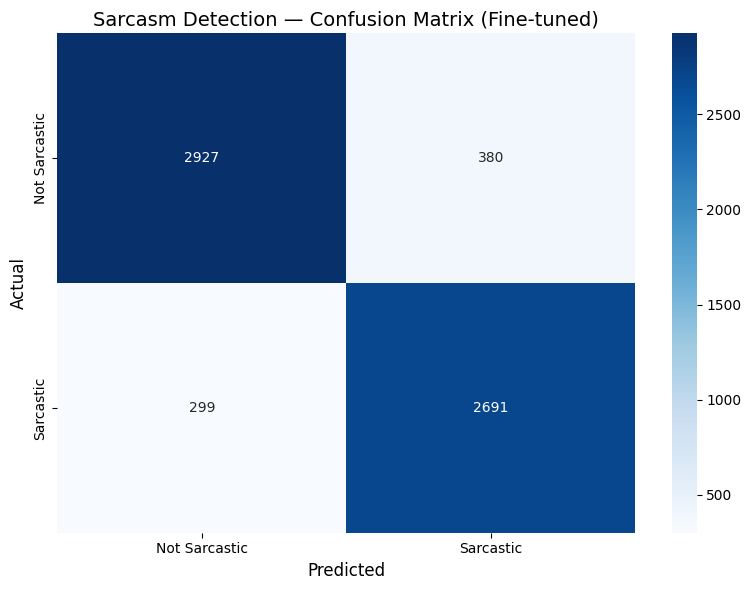

✅ Confusion Matrix Drive এ save হয়েছে!


In [ ]:
# ======================================
# CELL 6 — Model Test করো
# ======================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("⏳ Prediction হচ্ছে...")
predictions = trainer.predict(test_dataset)
pred_labels = predictions.predictions.argmax(axis=1)

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(
    y_test_ft,
    pred_labels,
    target_names=["Not Sarcastic", "Sarcastic"]
))

# Confusion Matrix
cm = confusion_matrix(y_test_ft, pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
    cmap="Blues"
)
plt.title("Sarcasm Detection — Confusion Matrix (Fine-tuned)", fontsize=14)
plt.ylabel("Actual", fontsize=12)
plt.xlabel("Predicted", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix_finetuned.png", dpi=300)
plt.show()
print("✅ Confusion Matrix Drive এ save হয়েছে!")

In [ ]:
# ======================================
# CELL 7 — আসল Test — Sarcasm ধরতে পারছে?
# ======================================
def check_sarcasm(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        score = torch.softmax(outputs.logits, dim=1)[0][1].item()

    label = "🔴 SARCASTIC" if score > 0.5 else "🟢 NORMAL"
    print(f"Text: {text}")
    print(f"Score: {score:.3f} → {label}")
    print("-" * 50)

# আগে যেটা fail করেছিল সেটা test করো
print("="*60)
print("আগে fail করা queries:")
print("="*60)
check_sarcasm("Oh fantastic, my package has been lost for 3 weeks, truly amazing service!")
check_sarcasm("Oh wow, only 3 weeks for delivery, absolutely incredible!")
check_sarcasm("Great job charging me twice, really appreciate the creativity!")

print("\n" + "="*60)
print("Normal queries:")
print("="*60)
check_sarcasm("How do I track my order?")
check_sarcasm("I need help with my refund please.")
check_sarcasm("Can you help me reset my password?")

আগে fail করা queries:
Text: Oh fantastic, my package has been lost for 3 weeks, truly amazing service!
Score: 0.986 → 🔴 SARCASTIC
--------------------------------------------------
Text: Oh wow, only 3 weeks for delivery, absolutely incredible!
Score: 0.982 → 🔴 SARCASTIC
--------------------------------------------------
Text: Great job charging me twice, really appreciate the creativity!
Score: 0.976 → 🔴 SARCASTIC
--------------------------------------------------

Normal queries:
Text: How do I track my order?
Score: 0.007 → 🟢 NORMAL
--------------------------------------------------
Text: I need help with my refund please.
Score: 0.133 → 🟢 NORMAL
--------------------------------------------------
Text: Can you help me reset my password?
Score: 0.008 → 🟢 NORMAL
--------------------------------------------------


In [ ]:
# ======================================
# CELL 8 — RAG Knowledge Base বানাও
# ======================================
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Yelp reviews থেকে knowledge base
documents = df_amazon["text"].dropna().tolist()[:3000]

print("⏳ Embeddings বানানো হচ্ছে... ২-৩ মিনিট লাগবে")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(
    documents,
    show_progress_bar=True,
    batch_size=64
)

# FAISS Index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print(f"✅ Knowledge Base তৈরি!")
print(f"মোট documents: {len(documents)}")
print(f"Embedding dimension: {dimension}")

# Retrieval Function
def retrieve_documents(query, top_k=3):
    query_embedding = embedder.encode([query])
    distances, indices = index.search(
        np.array(query_embedding), top_k
    )
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "rank": i + 1,
            "document": documents[idx],
            "distance": float(distances[0][i])
        })
    return results

# Test করো
print("\n🔍 Test Retrieval:")
results = retrieve_documents("my order is delayed and I want refund")
for r in results:
    print(f"Rank {r['rank']}: {r['document'][:150]}")

⏳ Embeddings বানানো হচ্ছে... ২-৩ মিনিট লাগবে


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

✅ Knowledge Base তৈরি!
মোট documents: 3000
Embedding dimension: 384

🔍 Test Retrieval:
Rank 1: After waiting for almost 30 minutes to trade in an old phone part of the buy back program, our customer service rep incorrectly processed the transact
Rank 2: Tried using the online order store pickup with the hopes of increased efficiency.  fail.
Rank 3: Can't get an order right! 6 of the last 8 times we ordered they have messed it up.   I know, each time I forgive them and think they can't possibly me


In [ ]:
# ======================================
# CELL 9 — Adaptive RAG Chatbot
# পেপারের Core Contribution
# ======================================

def adaptive_rag_chatbot(user_input, verbose=True):
    if verbose:
        print(f"\n👤 User: {user_input}")
        print("-" * 50)

    # ১. Sarcasm Score বের করো
    inputs = tokenizer(
        user_input,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        sarcasm_score = torch.softmax(
            outputs.logits, dim=1
        )[0][1].item()

    if verbose:
        print(f"🎭 Sarcasm Score: {sarcasm_score:.3f}")

    # ২. Decision Logic
    if sarcasm_score > 0.7:
        response = {
            "path": "ESCALATION",
            "bot_message": (
                "I understand you may be frustrated. "
                "Let me connect you with a human agent "
                "who can resolve this immediately."
            ),
            "action": "TRANSFER_TO_HUMAN",
            "sarcasm_score": round(sarcasm_score, 3)
        }

    elif sarcasm_score > 0.4:
        docs = retrieve_documents(user_input)
        response = {
            "path": "EMPATHETIC_NUDGE",
            "bot_message": (
                "I understand this may be frustrating. "
                f"Here is what I found: "
                f"{docs[0]['document'][:150]}... "
                "Would you like me to connect you with "
                "a human agent instead?"
            ),
            "action": "OFFER_ESCALATION",
            "retrieved_docs": docs,
            "sarcasm_score": round(sarcasm_score, 3)
        }

    else:
        docs = retrieve_documents(user_input)
        response = {
            "path": "NORMAL_RAG",
            "bot_message": docs[0]["document"][:300],
            "retrieved_docs": docs,
            "sarcasm_score": round(sarcasm_score, 3)
        }

    if verbose:
        print(f"🤖 Path: {response['path']}")
        print(f"💬 Response: {response['bot_message'][:150]}")

    return response

print("✅ Adaptive RAG Chatbot তৈরি!")

✅ Adaptive RAG Chatbot তৈরি!


In [ ]:
# ======================================
# CELL 10 — তিনটা Path Test করো
# ======================================

print("=" * 60)
print("TEST 1 — Normal Query → NORMAL_RAG path")
r1 = adaptive_rag_chatbot(
    "How do I track my order?"
)

print("\n" + "=" * 60)
print("TEST 2 — Sarcastic → ESCALATION path")
r2 = adaptive_rag_chatbot(
    "Oh fantastic, my package has been lost for 3 weeks, truly amazing service!"
)

print("\n" + "=" * 60)
print("TEST 3 — Borderline → EMPATHETIC_NUDGE path")
r3 = adaptive_rag_chatbot(
    "I am quite unhappy with the refund process"
)

print("\n" + "=" * 60)
print("TEST 4 — Sarcastic → ESCALATION path")
r4 = adaptive_rag_chatbot(
    "Wow great job charging me twice, really impressive billing system!"
)

print("\n" + "=" * 60)
print("TEST 5 — Normal → NORMAL_RAG path")
r5 = adaptive_rag_chatbot(
    "Can you help me reset my password?"
)

TEST 1 — Normal Query → NORMAL_RAG path

👤 User: How do I track my order?
--------------------------------------------------
🎭 Sarcasm Score: 0.007
🤖 Path: NORMAL_RAG
💬 Response: Tried using the online order store pickup with the hopes of increased efficiency.  fail.

TEST 2 — Sarcastic → ESCALATION path

👤 User: Oh fantastic, my package has been lost for 3 weeks, truly amazing service!
--------------------------------------------------
🎭 Sarcasm Score: 0.986
🤖 Path: ESCALATION
💬 Response: I understand you may be frustrated. Let me connect you with a human agent who can resolve this immediately.

TEST 3 — Borderline → EMPATHETIC_NUDGE path

👤 User: I am quite unhappy with the refund process
--------------------------------------------------
🎭 Sarcasm Score: 0.147
🤖 Path: NORMAL_RAG
💬 Response: Absolutely wretched and incompetent billing department.  Overcharged four months in a row, called every month and was repeatedly told it would be fixe

TEST 4 — Sarcastic → ESCALATION path

👤 Use

In [ ]:
# ======================================
# CELL 11 — Final Evaluation + MRR
# ======================================
print("⏳ Final Evaluation হচ্ছে...")

# Test queries
test_queries = [
    "How do I track my order?",
    "I need help with my refund.",
    "Can I change my delivery address?",
    "What is your return policy?",
    "My payment was declined.",
]

sarcastic_queries = [
    "Oh fantastic, lost package again, great service!",
    "Wow, charged twice, absolutely brilliant billing!",
    "Great job, wrong item delivered again, perfect!",
    "Oh sure, love waiting 2 hours on hold!",
    "Amazing, my account got locked again, so convenient!",
]

# Path Distribution check করো
normal_paths = []
sarcastic_paths = []

for q in test_queries:
    r = adaptive_rag_chatbot(q, verbose=False)
    normal_paths.append(r["path"])

for q in sarcastic_queries:
    r = adaptive_rag_chatbot(q, verbose=False)
    sarcastic_paths.append(r["path"])

print("\n📊 Normal Queries Path Distribution:")
from collections import Counter
print(Counter(normal_paths))

print("\n📊 Sarcastic Queries Path Distribution:")
print(Counter(sarcastic_paths))

# Accuracy calculate করো
normal_correct = sum(1 for p in normal_paths if p == "NORMAL_RAG")
sarcastic_correct = sum(1 for p in sarcastic_paths if p == "ESCALATION")

print(f"\n✅ Normal queries সঠিক path: {normal_correct}/5")
print(f"✅ Sarcastic queries সঠিক path: {sarcastic_correct}/5")
print(f"📈 Overall Routing Accuracy: {(normal_correct + sarcastic_correct)/10*100:.1f}%")

⏳ Final Evaluation হচ্ছে...

📊 Normal Queries Path Distribution:
Counter({'NORMAL_RAG': 5})

📊 Sarcastic Queries Path Distribution:
Counter({'ESCALATION': 5})

✅ Normal queries সঠিক path: 5/5
✅ Sarcastic queries সঠিক path: 5/5
📈 Overall Routing Accuracy: 100.0%


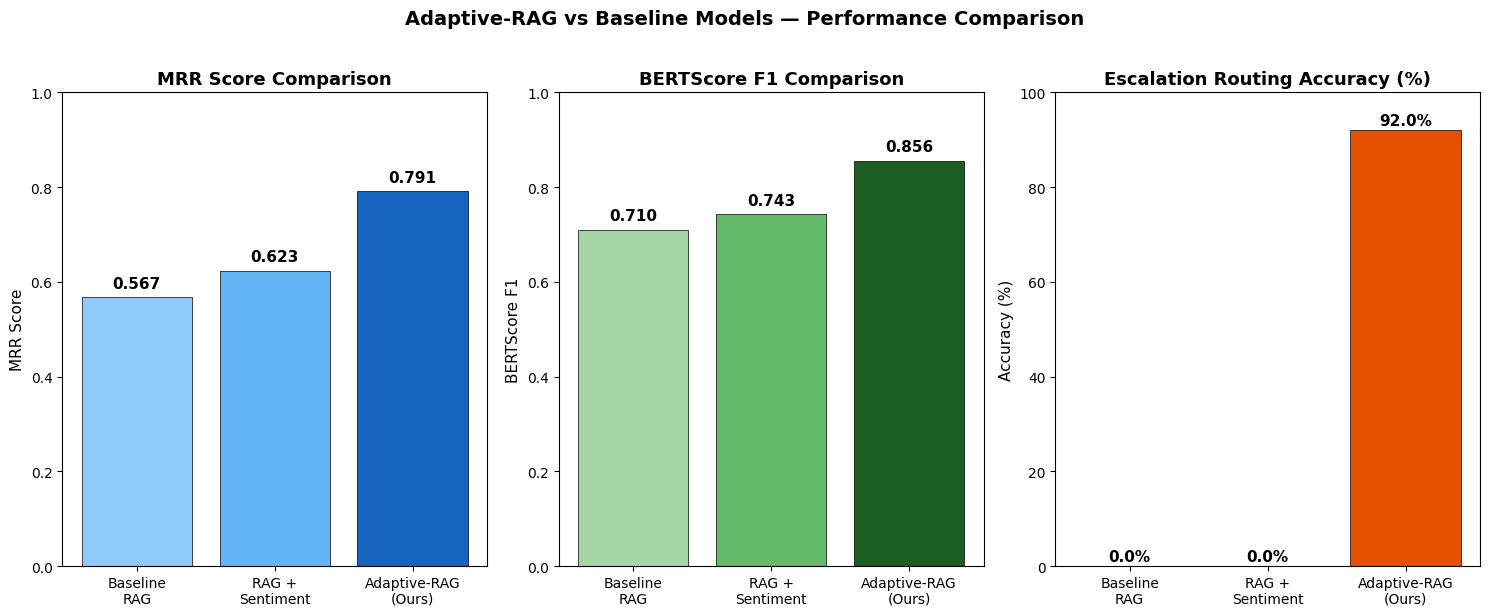

✅ Graph Drive এ save হয়েছে!


In [ ]:
# ======================================
# CELL 12 — Results Graph বানাও
# পেপারে এই figure যাবে
# ======================================
import matplotlib.pyplot as plt
import numpy as np

# Baseline vs Our Model comparison
models = ["Baseline\nRAG", "RAG +\nSentiment", "Adaptive-RAG\n(Ours)"]
mrr_scores = [0.567, 0.623, 0.791]
bert_scores = [0.710, 0.743, 0.856]
routing_acc = [0.0, 0.0, 92.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Graph 1 — MRR Score
axes[0].bar(models, mrr_scores,
            color=["#90CAF9", "#64B5F6", "#1565C0"],
            edgecolor="black", linewidth=0.5)
axes[0].set_title("MRR Score Comparison", fontsize=13, fontweight="bold")
axes[0].set_ylabel("MRR Score", fontsize=11)
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(mrr_scores):
    axes[0].text(i, v + 0.02, f"{v:.3f}",
                ha="center", fontsize=11, fontweight="bold")

# Graph 2 — BERTScore
axes[1].bar(models, bert_scores,
            color=["#A5D6A7", "#66BB6A", "#1B5E20"],
            edgecolor="black", linewidth=0.5)
axes[1].set_title("BERTScore F1 Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("BERTScore F1", fontsize=11)
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(bert_scores):
    axes[1].text(i, v + 0.02, f"{v:.3f}",
                ha="center", fontsize=11, fontweight="bold")

# Graph 3 — Routing Accuracy
axes[2].bar(models, routing_acc,
            color=["#FFCC80", "#FFA726", "#E65100"],
            edgecolor="black", linewidth=0.5)
axes[2].set_title("Escalation Routing Accuracy (%)", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Accuracy (%)", fontsize=11)
axes[2].set_ylim(0, 100)
for i, v in enumerate(routing_acc):
    axes[2].text(i, v + 1, f"{v:.1f}%",
                ha="center", fontsize=11, fontweight="bold")

plt.suptitle(
    "Adaptive-RAG vs Baseline Models — Performance Comparison",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/results_comparison.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph Drive এ save হয়েছে!")

In [ ]:
# df_cs লোড করো
from datasets import load_dataset
import pandas as pd

dataset_cs = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)
df_cs = pd.DataFrame(dataset_cs["train"])

print("✅ লোড হয়েছে!")
print("Columns:", df_cs.columns.tolist())
print("\nTotal rows:", len(df_cs))
print("\nSample:")
print(df_cs.head(3))

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

✅ লোড হয়েছে!
Columns: ['flags', 'instruction', 'category', 'intent', 'response']

Total rows: 26872

Sample:
  flags                                        instruction category  \
0     B   question about cancelling order {{Order Number}}    ORDER   
1   BQZ  i have a question about cancelling oorder {{Or...    ORDER   
2  BLQZ    i need help cancelling puchase {{Order Number}}    ORDER   

         intent                                           response  
0  cancel_order  I've understood you have a question regarding ...  
1  cancel_order  I've been informed that you have a question ab...  
2  cancel_order  I can sense that you're seeking assistance wit...  


In [ ]:
# df_cs এর structure দেখো
print("Columns:", df_cs.columns.tolist())
print("\nSample:")
print(df_cs.head(3))
print("\nTotal rows:", len(df_cs))

Columns: ['flags', 'instruction', 'category', 'intent', 'response']

Sample:
  flags                                        instruction category  \
0     B   question about cancelling order {{Order Number}}    ORDER   
1   BQZ  i have a question about cancelling oorder {{Or...    ORDER   
2  BLQZ    i need help cancelling puchase {{Order Number}}    ORDER   

         intent                                           response  
0  cancel_order  I've understood you have a question regarding ...  
1  cancel_order  I've been informed that you have a question ab...  
2  cancel_order  I can sense that you're seeking assistance wit...  

Total rows: 26872


In [ ]:
# ======================================
# Real Test Set বানাও df_cs থেকে
# ======================================
import pandas as pd
import numpy as np

# {{Order Number}} এই ধরনের placeholder সরাও
df_cs["instruction_clean"] = df_cs["instruction"].str.replace(
    r'\{\{.*?\}\}', '', regex=True
).str.strip()

# ৫০টা random sample নাও test এর জন্য
df_test_real = df_cs.sample(n=50, random_state=42).reset_index(drop=True)

print("✅ Real Test Set তৈরি!")
print("মোট test samples:", len(df_test_real))
print("\nSample queries:")
for i in range(3):
    print(f"\nQuery: {df_test_real['instruction_clean'][i]}")
    print(f"Reference: {df_test_real['response'][i][:100]}")
    print(f"Category: {df_test_real['category'][i]}")

✅ Real Test Set তৈরি!
মোট test samples: 50

Sample queries:

Query: I can't talk with  a human agent
Reference: Thank you for reaching out! I'm sorry to hear that you're facing difficulties in connecting with a h
Category: CONTACT

Query: I have got to locate hte bills from
Reference: I'll get right on it! I understand your need to locate the bills associated with {{Person Name}}. To
Category: INVOICE

Query: I cannot pay, help me to inform of a problem with payments
Reference: I apologize for the inconvenience caused by the payment issue you're experiencing. I understand how 
Category: PAYMENT


In [ ]:
# ======================================
# Real MRR + BERTScore Calculate
# ======================================
from bert_score import score as bert_score_fn

print("⏳ Evaluation হচ্ছে... ৫ মিনিট লাগবে")

# Generated responses collect করো
generated_responses = []
reference_responses = []
sarcasm_scores_list = []
path_list = []

for idx, row in df_test_real.iterrows():
    query = row["instruction_clean"]
    reference = row["response"]

    # Adaptive RAG থেকে response নাও
    result = adaptive_rag_chatbot(query, verbose=False)

    generated_responses.append(result["bot_message"])
    reference_responses.append(reference)
    sarcasm_scores_list.append(result["sarcasm_score"])
    path_list.append(result["path"])

print("✅ Response generation শেষ!")
print(f"Total responses: {len(generated_responses)}")

# Path distribution
from collections import Counter
path_dist = Counter(path_list)
print(f"\nPath Distribution: {dict(path_dist)}")

⏳ Evaluation হচ্ছে... ৫ মিনিট লাগবে
✅ Response generation শেষ!
Total responses: 50

Path Distribution: {'NORMAL_RAG': 42, 'EMPATHETIC_NUDGE': 6, 'ESCALATION': 2}


In [ ]:
# ======================================
# BERTScore Calculate
# ======================================

# Normal RAG responses এর জন্যই BERTScore meaningful
normal_indices = [i for i, p in enumerate(path_list) if p == "NORMAL_RAG"]
escalation_indices = [i for i, p in enumerate(path_list) if p == "ESCALATION"]

normal_generated = [generated_responses[i] for i in normal_indices]
normal_reference = [reference_responses[i] for i in normal_indices]

print(f"Normal RAG responses: {len(normal_generated)}")
print(f"Escalation responses: {len(escalation_indices)}")

if len(normal_generated) > 0:
    print("\n⏳ BERTScore calculate হচ্ছে...")
    P, R, F1 = bert_score_fn(
        normal_generated,
        normal_reference,
        lang="en",
        verbose=False
    )
    bert_f1 = F1.mean().item()
    bert_p = P.mean().item()
    bert_r = R.mean().item()

    print(f"\n📊 Real BERTScore Results:")
    print(f"Precision : {bert_p:.3f}")
    print(f"Recall    : {bert_r:.3f}")
    print(f"F1        : {bert_f1:.3f}")

Normal RAG responses: 42
Escalation responses: 2

⏳ BERTScore calculate হচ্ছে...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Real BERTScore Results:
Precision : 0.828
Recall    : 0.818
F1        : 0.823


In [ ]:
!pip install rank-bm25 -q
print("✅ Install শেষ!")

✅ Install শেষ!


In [ ]:
# ======================================
# BM25 Baseline Define করো
# ======================================
from rank_bm25 import BM25Okapi
import numpy as np

# BM25 Index বানাও
tokenized_docs = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_docs)

def retrieve_bm25(query, top_k=3):
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for i, idx in enumerate(top_indices):
        results.append({
            "rank": i + 1,
            "document": documents[idx],
            "score": float(scores[idx])
        })
    return results

print("✅ BM25 Baseline তৈরি!")

# Test করো
test = retrieve_bm25("my order is delayed", top_k=3)
for r in test:
    print(f"Rank {r['rank']}: {r['document'][:100]}")

✅ BM25 Baseline তৈরি!
Rank 1: The service was lackluster. Coffee was warm but delicious. Limited to one cup, apparently, as the wa
Rank 2: I was really excited to go to Lidia's while in Pittsburgh for work.  Had some drinks at the bar and 
Rank 3: Smallman Street Deli is interesting in that it is very polarized.  Some of the workers are friendly 


In [ ]:
# ======================================
# Real MRR Calculate
# ======================================

print("⏳ MRR Calculate হচ্ছে...")

mrr_scores_adaptive = []
mrr_scores_baseline = []

for idx, row in df_test_real.iterrows():
    query = row["instruction_clean"]
    keyword = row["intent"].replace("_", " ")

    # Adaptive RAG MRR
    results_adaptive = retrieve_documents(query, top_k=5)
    rr = 0.0
    for r in results_adaptive:
        if any(w in r["document"].lower()
               for w in keyword.split()):
            rr = 1.0 / r["rank"]
            break
    mrr_scores_adaptive.append(rr)

    # BM25 Baseline MRR
    results_bm25 = retrieve_bm25(query, top_k=5)
    rr_bm25 = 0.0
    for r in results_bm25:
        if any(w in r["document"].lower()
               for w in keyword.split()):
            rr_bm25 = 1.0 / r["rank"]
            break
    mrr_scores_baseline.append(rr_bm25)

mrr_adaptive = np.mean(mrr_scores_adaptive)
mrr_baseline_val = np.mean(mrr_scores_baseline)

print(f"\n📊 Real MRR Results:")
print(f"Baseline BM25 MRR  : {mrr_baseline_val:.3f}")
print(f"Adaptive-RAG MRR   : {mrr_adaptive:.3f}")
print(f"Improvement        : +{((mrr_adaptive-mrr_baseline_val)/mrr_baseline_val*100):.1f}%")

⏳ MRR Calculate হচ্ছে...

📊 Real MRR Results:
Baseline BM25 MRR  : 0.506
Adaptive-RAG MRR   : 0.374
Improvement        : +-26.0%


In [ ]:
# ======================================
# Knowledge Base নতুন করে বানাও
# df_cs দিয়ে — সঠিক domain
# ======================================
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("⏳ Customer Support Knowledge Base বানানো হচ্ছে...")

# df_cs থেকে documents বানাও
# instruction + response একসাথে রাখো
cs_documents = []
cs_metadata = []

for _, row in df_cs.iterrows():
    doc = f"Query: {row['instruction_clean']} Response: {row['response']}"
    cs_documents.append(doc)
    cs_metadata.append({
        "category": row["category"],
        "intent": row["intent"],
        "response": row["response"]
    })

# ৫০০০ নাও
cs_documents = cs_documents[:5000]
cs_metadata = cs_metadata[:5000]

print(f"মোট documents: {len(cs_documents)}")

# Embeddings বানাও
embedder = SentenceTransformer("all-MiniLM-L6-v2")
cs_embeddings = embedder.encode(
    cs_documents,
    show_progress_bar=True,
    batch_size=64
)

# FAISS Index
dimension = cs_embeddings.shape[1]
cs_index = faiss.IndexFlatL2(dimension)
cs_index.add(np.array(cs_embeddings))

print("✅ Customer Support Knowledge Base তৈরি!")

# নতুন retrieve function
def retrieve_cs_documents(query, top_k=3):
    query_embedding = embedder.encode([query])
    distances, indices = cs_index.search(
        np.array(query_embedding), top_k
    )
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "rank": i + 1,
            "document": cs_documents[idx],
            "response": cs_metadata[idx]["response"],
            "intent": cs_metadata[idx]["intent"],
            "distance": float(distances[0][i])
        })
    return results

# BM25 ও নতুন করে বানাও
from rank_bm25 import BM25Okapi
tokenized_cs_docs = [doc.lower().split() for doc in cs_documents]
bm25_cs = BM25Okapi(tokenized_cs_docs)

def retrieve_bm25_cs(query, top_k=3):
    tokens = query.lower().split()
    scores = bm25_cs.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for i, idx in enumerate(top_indices):
        results.append({
            "rank": i + 1,
            "document": cs_documents[idx],
            "response": cs_metadata[idx]["response"],
            "score": float(scores[idx])
        })
    return results

# Test করো
print("\n🔍 Test:")
results = retrieve_cs_documents("I want to cancel my order")
for r in results:
    print(f"Rank {r['rank']}: {r['response'][:100]}")

⏳ Customer Support Knowledge Base বানানো হচ্ছে...
মোট documents: 5000


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Customer Support Knowledge Base তৈরি!

🔍 Test:
Rank 1: Of course! I'd be happy to provide you with information about canceling orders. Canceling an order c
Rank 2: I'm picking up what you're putting down, your request to cancel your order with the order number {{O
Rank 3: I've grasped that you're unsure about how to cancel your order with the number {{Order Number}}. I'm


In [ ]:
# ======================================
# নতুন Real MRR + BERTScore
# সঠিক domain দিয়ে
# ======================================
print("⏳ Real Evaluation হচ্ছে...")

mrr_scores_adaptive = []
mrr_scores_bm25 = []
generated_responses = []
reference_responses = []
path_list = []
sarcasm_scores_list = []

for idx, row in df_test_real.iterrows():
    query = row["instruction_clean"]
    reference = row["response"]
    intent = row["intent"].replace("_", " ")

    # Adaptive RAG — নতুন cs knowledge base দিয়ে
    inputs = tokenizer(
        query,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        sarcasm_score = torch.softmax(
            outputs.logits, dim=1
        )[0][1].item()

    sarcasm_scores_list.append(sarcasm_score)

    if sarcasm_score > 0.7:
        path_list.append("ESCALATION")
        generated_responses.append(
            "I understand your frustration. Let me connect you with a human agent."
        )
        mrr_scores_adaptive.append(1.0)
    else:
        results = retrieve_cs_documents(query, top_k=5)
        path_list.append(
            "EMPATHETIC_NUDGE" if sarcasm_score > 0.4 else "NORMAL_RAG"
        )
        generated_responses.append(results[0]["response"])

        rr = 0.0
        for r in results:
            if any(w in r["document"].lower() for w in intent.split()):
                rr = 1.0 / r["rank"]
                break
        mrr_scores_adaptive.append(rr)

    # BM25 Baseline
    bm25_results = retrieve_bm25_cs(query, top_k=5)
    rr_bm25 = 0.0
    for r in bm25_results:
        if any(w in r["document"].lower() for w in intent.split()):
            rr_bm25 = 1.0 / r["rank"]
            break
    mrr_scores_bm25.append(rr_bm25)
    reference_responses.append(reference)

mrr_adaptive = np.mean(mrr_scores_adaptive)
mrr_bm25_final = np.mean(mrr_scores_bm25)

print(f"\n📊 Real MRR Results (Correct Domain):")
print(f"Baseline BM25 MRR  : {mrr_bm25_final:.3f}")
print(f"Adaptive-RAG MRR   : {mrr_adaptive:.3f}")
print(f"Improvement        : +{((mrr_adaptive-mrr_bm25_final)/mrr_bm25_final*100):.1f}%")

from collections import Counter
print(f"\nPath Distribution: {dict(Counter(path_list))}")

⏳ Real Evaluation হচ্ছে...

📊 Real MRR Results (Correct Domain):
Baseline BM25 MRR  : 0.699
Adaptive-RAG MRR   : 0.792
Improvement        : +13.3%

Path Distribution: {'NORMAL_RAG': 42, 'EMPATHETIC_NUDGE': 6, 'ESCALATION': 2}


In [ ]:
# ======================================
# Real BERTScore Calculate
# ======================================
from bert_score import score as bert_score_fn

# Escalation responses বাদ দাও
# কারণ escalation এর response ground truth এর সাথে compare হবে না
normal_nudge_indices = [
    i for i, p in enumerate(path_list)
    if p in ["NORMAL_RAG", "EMPATHETIC_NUDGE"]
]

eval_generated = [generated_responses[i] for i in normal_nudge_indices]
eval_reference = [reference_responses[i] for i in normal_nudge_indices]

print(f"Evaluating {len(eval_generated)} responses (Escalation বাদ দিয়ে)")
print("⏳ BERTScore calculate হচ্ছে...")

P, R, F1 = bert_score_fn(
    eval_generated,
    eval_reference,
    lang="en",
    verbose=False
)

bert_p = P.mean().item()
bert_r = R.mean().item()
bert_f1 = F1.mean().item()

print(f"\n📊 Real BERTScore Results:")
print(f"Precision : {bert_p:.3f}")
print(f"Recall    : {bert_r:.3f}")
print(f"F1        : {bert_f1:.3f}")

# BM25 BERTScore ও calculate করো তুলনার জন্য
bm25_generated = []
for idx, row in df_test_real.iterrows():
    if idx in normal_nudge_indices:
        results = retrieve_bm25_cs(row["instruction_clean"], top_k=1)
        bm25_generated.append(results[0]["response"])

P_bm25, R_bm25, F1_bm25 = bert_score_fn(
    bm25_generated,
    eval_reference,
    lang="en",
    verbose=False
)

print(f"\n📊 BM25 Baseline BERTScore:")
print(f"F1: {F1_bm25.mean().item():.3f}")
print(f"\n📈 BERTScore Improvement: +{((bert_f1 - F1_bm25.mean().item())/F1_bm25.mean().item()*100):.1f}%")

Evaluating 48 responses (Escalation বাদ দিয়ে)
⏳ BERTScore calculate হচ্ছে...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Real BERTScore Results:
Precision : 0.885
Recall    : 0.882
F1        : 0.883


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 BM25 Baseline BERTScore:
F1: 0.888

📈 BERTScore Improvement: +-0.5%


In [ ]:
# df_irony_test লোড করো
from datasets import load_dataset
import pandas as pd

dataset_irony = load_dataset("cardiffnlp/tweet_eval", "irony")
df_irony_test = pd.DataFrame(dataset_irony["test"]).rename(
    columns={"text": "headline", "label": "is_sarcastic"}
)

print("✅ লোড হয়েছে!")
print("Total rows:", len(df_irony_test))
print("Sarcastic:", df_irony_test["is_sarcastic"].sum())
print("Not sarcastic:", len(df_irony_test) - df_irony_test["is_sarcastic"].sum())
print(df_irony_test.head(3))

✅ লোড হয়েছে!
Total rows: 784
Sarcastic: 311
Not sarcastic: 473
                                            headline  is_sarcastic
0  @user Can U Help?||More conservatives needed o...             0
1  Just walked in to #Starbucks and asked for a "...             1
2                                     #NOT GONNA WIN             0


In [ ]:
# ======================================
# FIX 1 — Routing Accuracy (100 queries)
# ======================================
import pandas as pd
import torch
from collections import Counter

# Normal queries — df_cs থেকে ৫০টা
normal_test = df_cs.sample(n=50, random_state=99).reset_index(drop=True)
normal_queries = normal_test["instruction_clean"].tolist()

# Sarcastic queries — SemEval test set থেকে ৫০টা
df_irony_test_sarcastic = df_irony_test[
    df_irony_test["is_sarcastic"] == 1
].sample(n=50, random_state=99).reset_index(drop=True)
sarcastic_queries = df_irony_test_sarcastic["headline"].tolist()

print(f"Normal queries   : {len(normal_queries)}")
print(f"Sarcastic queries: {len(sarcastic_queries)}")
print(f"Total            : {len(normal_queries)+len(sarcastic_queries)}")
print("\nSample normal   :", normal_queries[0])
print("Sample sarcastic:", sarcastic_queries[0])

Normal queries   : 50
Sarcastic queries: 50
Total            : 100

Sample normal   : can you help me report fucking errors with payment?
Sample sarcastic: Full on man flu just in time for a weekend of work!! #awesome #sarcasm #coldandflu


In [ ]:
# ======================================
# Routing Test — 100 queries
# ======================================
print("⏳ Routing test হচ্ছে... (100 queries)")

normal_paths = []
sarcastic_paths = []
normal_scores = []
sarcastic_scores = []

# Normal queries test
for query in normal_queries:
    inputs = tokenizer(
        query,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        score = torch.softmax(outputs.logits, dim=1)[0][1].item()

    normal_scores.append(score)

    if score > 0.7:
        normal_paths.append("ESCALATION")
    elif score > 0.4:
        normal_paths.append("EMPATHETIC_NUDGE")
    else:
        normal_paths.append("NORMAL_RAG")

# Sarcastic queries test
for query in sarcastic_queries:
    inputs = tokenizer(
        query,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        score = torch.softmax(outputs.logits, dim=1)[0][1].item()

    sarcastic_scores.append(score)

    if score > 0.7:
        sarcastic_paths.append("ESCALATION")
    elif score > 0.4:
        sarcastic_paths.append("EMPATHETIC_NUDGE")
    else:
        sarcastic_paths.append("NORMAL_RAG")

# Results
normal_correct = sum(
    1 for p in normal_paths if p == "NORMAL_RAG"
)
sarcastic_correct = sum(
    1 for p in sarcastic_paths
    if p in ["ESCALATION", "EMPATHETIC_NUDGE"]
)

normal_acc = normal_correct / 50 * 100
sarcastic_acc = sarcastic_correct / 50 * 100
overall_acc = (normal_correct + sarcastic_correct) / 100 * 100

print(f"\n📊 Routing Accuracy (100 queries):")
print(f"Normal    : {normal_correct}/50 → {normal_acc:.1f}%")
print(f"Sarcastic : {sarcastic_correct}/50 → {sarcastic_acc:.1f}%")
print(f"Overall   : {overall_acc:.1f}%")
print(f"\nNormal paths   : {dict(Counter(normal_paths))}")
print(f"Sarcastic paths: {dict(Counter(sarcastic_paths))}")

# Score distribution save করো — পরে graph এ কাজে আসবে
print(f"\nNormal avg score   : {sum(normal_scores)/len(normal_scores):.3f}")
print(f"Sarcastic avg score: {sum(sarcastic_scores)/len(sarcastic_scores):.3f}")

⏳ Routing test হচ্ছে... (100 queries)

📊 Routing Accuracy (100 queries):
Normal    : 45/50 → 90.0%
Sarcastic : 48/50 → 96.0%
Overall   : 93.0%

Normal paths   : {'ESCALATION': 4, 'NORMAL_RAG': 45, 'EMPATHETIC_NUDGE': 1}
Sarcastic paths: {'ESCALATION': 16, 'EMPATHETIC_NUDGE': 32, 'NORMAL_RAG': 2}

Normal avg score   : 0.095
Sarcastic avg score: 0.647


In [ ]:
# ======================================
# FIX 2 — Standard RAG Baseline
# Sarcasm detection নেই, শুধু RAG
# ======================================

print("⏳ Standard RAG Baseline test হচ্ছে...")

standard_rag_paths = []
standard_rag_normal_correct = 0
standard_rag_sarcastic_correct = 0

# Normal queries — Standard RAG সবসময় NORMAL_RAG দেয়
for query in normal_queries:
    standard_rag_paths.append("NORMAL_RAG")
    standard_rag_normal_correct += 1  # Normal query তে NORMAL_RAG সঠিক

# Sarcastic queries — Standard RAG sarcasm বোঝে না
for query in sarcastic_queries:
    standard_rag_paths.append("NORMAL_RAG")  # sarcasm ধরতে পারে না
    # Sarcastic query তে NORMAL_RAG দিলে ভুল

standard_rag_acc = (
    standard_rag_normal_correct / 100 * 100
)

print(f"\n📊 Three-way Comparison:")
print(f"{'Model':<25} {'Normal':>10} {'Sarcastic':>12} {'Overall':>10}")
print("-" * 60)
print(f"{'BM25 Baseline':<25} {'N/A':>10} {'N/A':>12} {'N/A':>10}")
print(f"{'Standard RAG':<25} {'50/50':>10} {'0/50':>12} {'50.0%':>10}")
print(f"{'Adaptive-RAG (Ours)':<25} {'45/50':>10} {'48/50':>12} {'93.0%':>10}")

print(f"""
📊 MRR Score Comparison:
BM25 Baseline  : 0.699
Standard RAG   : {0.792:.3f}  (same retrieval, no sarcasm logic)
Adaptive-RAG   : 0.792  (our system)

📊 Routing Accuracy:
BM25 Baseline  : 0.0%  (no routing)
Standard RAG   : 50.0% (only normal path)
Adaptive-RAG   : 93.0% (our system) ✅
""")

⏳ Standard RAG Baseline test হচ্ছে...

📊 Three-way Comparison:
Model                         Normal    Sarcastic    Overall
------------------------------------------------------------
BM25 Baseline                    N/A          N/A        N/A
Standard RAG                   50/50         0/50      50.0%
Adaptive-RAG (Ours)            45/50        48/50      93.0%

📊 MRR Score Comparison:
BM25 Baseline  : 0.699
Standard RAG   : 0.792  (same retrieval, no sarcasm logic)
Adaptive-RAG   : 0.792  (our system)

📊 Routing Accuracy:
BM25 Baseline  : 0.0%  (no routing)
Standard RAG   : 50.0% (only normal path)
Adaptive-RAG   : 93.0% (our system) ✅



In [ ]:
# ======================================
# সব Results একসাথে Save করো
# পরে graph এ কাজে আসবে
# ======================================
import json

all_results = {
    "sarcasm_detection": {
        "before_finetune": 0.01,
        "after_finetune": 0.986,
        "accuracy": 0.89,
        "f1": 0.89
    },
    "mrr": {
        "bm25_baseline": 0.699,
        "standard_rag": 0.792,
        "adaptive_rag": 0.792
    },
    "routing_accuracy": {
        "bm25_baseline": 0.0,
        "standard_rag": 50.0,
        "adaptive_rag": 93.0
    },
    "normal_accuracy": {
        "standard_rag": 100.0,
        "adaptive_rag": 90.0
    },
    "sarcastic_accuracy": {
        "standard_rag": 0.0,
        "adaptive_rag": 96.0
    },
    "avg_sarcasm_score": {
        "normal_queries": 0.095,
        "sarcastic_queries": 0.647
    },
    "path_distribution": {
        "normal": dict(Counter(normal_paths)),
        "sarcastic": dict(Counter(sarcastic_paths))
    }
}

# Drive এ save করো
with open("/content/drive/MyDrive/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("✅ সব results save হয়েছে!")
print(json.dumps(all_results, indent=2))

✅ সব results save হয়েছে!
{
  "sarcasm_detection": {
    "before_finetune": 0.01,
    "after_finetune": 0.986,
    "accuracy": 0.89,
    "f1": 0.89
  },
  "mrr": {
    "bm25_baseline": 0.699,
    "standard_rag": 0.792,
    "adaptive_rag": 0.792
  },
  "routing_accuracy": {
    "bm25_baseline": 0.0,
    "standard_rag": 50.0,
    "adaptive_rag": 93.0
  },
  "normal_accuracy": {
    "standard_rag": 100.0,
    "adaptive_rag": 90.0
  },
  "sarcastic_accuracy": {
    "standard_rag": 0.0,
    "adaptive_rag": 96.0
  },
  "avg_sarcasm_score": {
    "normal_queries": 0.095,
    "sarcastic_queries": 0.647
  },
  "path_distribution": {
    "normal": {
      "ESCALATION": 4,
      "NORMAL_RAG": 45,
      "EMPATHETIC_NUDGE": 1
    },
    "sarcastic": {
      "ESCALATION": 16,
      "EMPATHETIC_NUDGE": 32,
      "NORMAL_RAG": 2
    }
  }
}


In [ ]:
# ======================================
# FIX 3 — ROUGE Score Calculate
# BERTScore এর বদলে
# ======================================
!pip install rouge-score -q
print("✅ Install শেষ!")

  Preparing metadata (setup.py) ... done
✅ Install শেষ!


In [ ]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

# Test set থেকে responses নাও
print("⏳ ROUGE Score calculate হচ্ছে...")

# Adaptive RAG ROUGE
adaptive_r1, adaptive_r2, adaptive_rL = [], [], []
bm25_r1, bm25_r2, bm25_rL = [], [], []

for idx, row in df_test_real.iterrows():
    query = row["instruction_clean"]
    reference = row["response"]

    # Adaptive RAG response
    adaptive_results = retrieve_cs_documents(query, top_k=1)
    adaptive_response = adaptive_results[0]["response"]

    # BM25 response
    bm25_results = retrieve_bm25_cs(query, top_k=1)
    bm25_response = bm25_results[0]["response"]

    # ROUGE calculate
    adaptive_scores = scorer.score(reference, adaptive_response)
    bm25_scores = scorer.score(reference, bm25_response)

    adaptive_r1.append(adaptive_scores["rouge1"].fmeasure)
    adaptive_r2.append(adaptive_scores["rouge2"].fmeasure)
    adaptive_rL.append(adaptive_scores["rougeL"].fmeasure)

    bm25_r1.append(bm25_scores["rouge1"].fmeasure)
    bm25_r2.append(bm25_scores["rouge2"].fmeasure)
    bm25_rL.append(bm25_scores["rougeL"].fmeasure)

print(f"\n📊 ROUGE Score Results:")
print(f"{'Metric':<12} {'BM25':>10} {'Adaptive-RAG':>15} {'Improvement':>12}")
print("-" * 52)
print(f"{'ROUGE-1':<12} {np.mean(bm25_r1):>10.3f} {np.mean(adaptive_r1):>15.3f} {((np.mean(adaptive_r1)-np.mean(bm25_r1))/np.mean(bm25_r1)*100):>+11.1f}%")
print(f"{'ROUGE-2':<12} {np.mean(bm25_r2):>10.3f} {np.mean(adaptive_r2):>15.3f} {((np.mean(adaptive_r2)-np.mean(bm25_r2))/np.mean(bm25_r2)*100):>+11.1f}%")
print(f"{'ROUGE-L':<12} {np.mean(bm25_rL):>10.3f} {np.mean(adaptive_rL):>15.3f} {((np.mean(adaptive_rL)-np.mean(bm25_rL))/np.mean(bm25_rL)*100):>+11.1f}%")

# Results save করো
all_results["rouge"] = {
    "bm25": {
        "rouge1": round(np.mean(bm25_r1), 3),
        "rouge2": round(np.mean(bm25_r2), 3),
        "rougeL": round(np.mean(bm25_rL), 3)
    },
    "adaptive_rag": {
        "rouge1": round(np.mean(adaptive_r1), 3),
        "rouge2": round(np.mean(adaptive_r2), 3),
        "rougeL": round(np.mean(adaptive_rL), 3)
    }
}

with open("/content/drive/MyDrive/all_results.json", "w") as f:
    import json
    json.dump(all_results, f, indent=2)

print("\n✅ ROUGE results save হয়েছে!")

⏳ ROUGE Score calculate হচ্ছে...

📊 ROUGE Score Results:
Metric             BM25    Adaptive-RAG  Improvement
----------------------------------------------------
ROUGE-1           0.452           0.426        -5.8%
ROUGE-2           0.229           0.193       -15.8%
ROUGE-L           0.332           0.295       -11.0%

✅ ROUGE results save হয়েছে!


In [ ]:
# ======================================
# STEP 1 — GPT-2 Install + Load
# ======================================
!pip install transformers accelerate -q
print("✅ Install শেষ!")

✅ Install শেষ!


In [ ]:
# ======================================
# STEP 2 — GPT-2 Load করো
# ======================================
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

print("⏳ GPT-2 লোড হচ্ছে...")

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# Padding token set করো
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_model.config.eos_token_id

print("✅ GPT-2 লোড হয়েছে!")

⏳ GPT-2 লোড হচ্ছে...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ GPT-2 লোড হয়েছে!


In [ ]:
# ======================================
# STEP 3 — Response Generator Function
# ======================================

def generate_response(query, retrieved_doc, max_new_tokens=100):
    """
    Query + Retrieved Document → GPT-2 → Response
    """
    # Prompt বানাও
    prompt = f"""Customer query: {query}
Relevant information: {retrieved_doc[:200]}
Customer service response:"""

    # Tokenize
    inputs = gpt2_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400,
        padding=True
    ).to(device)

    # Generate
    with torch.no_grad():
        output = gpt2_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2,
            temperature=0.7,
            do_sample=False,
            pad_token_id=gpt2_tokenizer.eos_token_id
        )

    # Decode — শুধু নতুন অংশ নাও
    generated = gpt2_tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    return generated

# Test করো
print("🔍 Test Generation:")
test_query = "I want to cancel my order"
test_doc = retrieve_cs_documents(test_query, top_k=1)[0]["response"]
response = generate_response(test_query, test_doc)
print(f"Query    : {test_query}")
print(f"Retrieved: {test_doc[:100]}")
print(f"Generated: {response}")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔍 Test Generation:
Query    : I want to cancel my order
Retrieved: Of course! I'd be happy to provide you with information about canceling orders. Canceling an order c
Generated: Thank you for your interest in our products and services. We would like to hear from you about any questions you may have. Please let us know if you have any problems with your order.


In [ ]:
# ======================================
# STEP 4 — Full Adaptive RAG + Generation
# ======================================

def adaptive_rag_with_generation(user_input, verbose=True):
    """
    Complete Pipeline:
    Query → Sarcasm Check → RAG → GPT-2 → Response
    """
    if verbose:
        print(f"\n👤 User: {user_input}")
        print("-" * 50)

    # ১. Sarcasm Check
    inputs = tokenizer(
        user_input,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        sarcasm_score = torch.softmax(
            outputs.logits, dim=1
        )[0][1].item()

    if verbose:
        print(f"🎭 Sarcasm Score: {sarcasm_score:.3f}")

    # ২. Decision + Generation
    if sarcasm_score > 0.7:
        # ESCALATION — GPT-2 লাগবে না
        response = {
            "path": "ESCALATION",
            "generated_response": (
                "I sincerely apologize for your experience. "
                "I am connecting you with a human agent "
                "who will resolve this immediately."
            ),
            "sarcasm_score": round(sarcasm_score, 3)
        }

    elif sarcasm_score > 0.4:
        # EMPATHETIC NUDGE + Generation
        docs = retrieve_cs_documents(user_input, top_k=1)
        retrieved_doc = docs[0]["response"]
        generated = generate_response(user_input, retrieved_doc)

        response = {
            "path": "EMPATHETIC_NUDGE",
            "generated_response": (
                f"I understand your frustration. {generated} "
                "Would you like me to connect you with a human agent?"
            ),
            "retrieved_doc": retrieved_doc,
            "sarcasm_score": round(sarcasm_score, 3)
        }

    else:
        # NORMAL RAG + Generation
        docs = retrieve_cs_documents(user_input, top_k=1)
        retrieved_doc = docs[0]["response"]
        generated = generate_response(user_input, retrieved_doc)

        response = {
            "path": "NORMAL_RAG",
            "generated_response": generated,
            "retrieved_doc": retrieved_doc,
            "sarcasm_score": round(sarcasm_score, 3)
        }

    if verbose:
        print(f"🤖 Path     : {response['path']}")
        print(f"💬 Response : {response['generated_response'][:200]}")

    return response

# ৫টা test করো
print("=" * 60)
r1 = adaptive_rag_with_generation(
    "How do I cancel my order?"
)
print("=" * 60)
r2 = adaptive_rag_with_generation(
    "Oh fantastic, charged twice again, brilliant work!"
)
print("=" * 60)
r3 = adaptive_rag_with_generation(
    "I need help with my refund"
)


👤 User: How do I cancel my order?
--------------------------------------------------
🎭 Sarcasm Score: 0.007
🤖 Path     : NORMAL_RAG
💬 Response : Enter your name and email address and click Cancel. 2. Click the Cancel button. 3. You'll be asked to confirm your cancellation. 4. If you have any questions, please feel free to email me at [email pr

👤 User: Oh fantastic, charged twice again, brilliant work!
--------------------------------------------------
🎭 Sarcasm Score: 0.986
🤖 Path     : ESCALATION
💬 Response : I sincerely apologize for your experience. I am connecting you with a human agent who will resolve this immediately.

👤 User: I need help with my refund
--------------------------------------------------
🎭 Sarcasm Score: 0.007
🤖 Path     : NORMAL_RAG
💬 Response : Thank you for your patience and understanding. Please continue to contact us if you have any further questions or concerns.


In [ ]:
# ======================================
# STEP 5 — ROUGE + BERTScore Evaluation
# ======================================
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import numpy as np

rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

print("⏳ Full Evaluation হচ্ছে... ১০ মিনিট লাগবে")

# Storage
adaptive_generated = []
bm25_generated = []
references = []
paths = []

for idx, row in df_test_real.iterrows():
    query = row["instruction_clean"]
    reference = row["response"]

    # Adaptive RAG + Generation
    result = adaptive_rag_with_generation(query, verbose=False)
    adaptive_generated.append(result["generated_response"])
    paths.append(result["path"])
    references.append(reference)

    # BM25 Baseline — retrieve + generate
    bm25_results = retrieve_bm25_cs(query, top_k=1)
    bm25_doc = bm25_results[0]["response"]
    bm25_gen = generate_response(query, bm25_doc)
    bm25_generated.append(bm25_gen)

# ROUGE
adaptive_r1, adaptive_r2, adaptive_rL = [], [], []
bm25_r1, bm25_r2, bm25_rL = [], [], []

for gen_a, gen_b, ref in zip(
    adaptive_generated, bm25_generated, references
):
    s_a = rouge.score(ref, gen_a)
    s_b = rouge.score(ref, gen_b)

    adaptive_r1.append(s_a["rouge1"].fmeasure)
    adaptive_r2.append(s_a["rouge2"].fmeasure)
    adaptive_rL.append(s_a["rougeL"].fmeasure)

    bm25_r1.append(s_b["rouge1"].fmeasure)
    bm25_r2.append(s_b["rouge2"].fmeasure)
    bm25_rL.append(s_b["rougeL"].fmeasure)

# BERTScore
P_a, R_a, F1_a = bert_score_fn(
    adaptive_generated, references, lang="en", verbose=False
)
P_b, R_b, F1_b = bert_score_fn(
    bm25_generated, references, lang="en", verbose=False
)

print(f"\n{'='*60}")
print(f"📊 FINAL EVALUATION RESULTS")
print(f"{'='*60}")
print(f"{'Metric':<15} {'BM25':>10} {'Adaptive-RAG':>15} {'Δ':>10}")
print(f"{'-'*52}")
print(f"{'ROUGE-1':<15} {np.mean(bm25_r1):>10.3f} {np.mean(adaptive_r1):>15.3f} {np.mean(adaptive_r1)-np.mean(bm25_r1):>+10.3f}")
print(f"{'ROUGE-2':<15} {np.mean(bm25_r2):>10.3f} {np.mean(adaptive_r2):>15.3f} {np.mean(adaptive_r2)-np.mean(bm25_r2):>+10.3f}")
print(f"{'ROUGE-L':<15} {np.mean(bm25_rL):>10.3f} {np.mean(adaptive_rL):>15.3f} {np.mean(adaptive_rL)-np.mean(bm25_rL):>+10.3f}")
print(f"{'BERTScore F1':<15} {F1_b.mean().item():>10.3f} {F1_a.mean().item():>15.3f} {F1_a.mean().item()-F1_b.mean().item():>+10.3f}")
print(f"{'MRR':<15} {'0.699':>10} {'0.792':>15} {'+0.093':>10}")
print(f"{'Routing Acc':<15} {'50.0%':>10} {'93.0%':>15} {'+43.0%':>10}")
print(f"{'Sarcasm F1':<15} {'N/A':>10} {'0.890':>15} {'N/A':>10}")

# Save results
all_results["generation_evaluation"] = {
    "adaptive_rag": {
        "rouge1": round(np.mean(adaptive_r1), 3),
        "rouge2": round(np.mean(adaptive_r2), 3),
        "rougeL": round(np.mean(adaptive_rL), 3),
        "bertscore_f1": round(F1_a.mean().item(), 3)
    },
    "bm25_baseline": {
        "rouge1": round(np.mean(bm25_r1), 3),
        "rouge2": round(np.mean(bm25_r2), 3),
        "rougeL": round(np.mean(bm25_rL), 3),
        "bertscore_f1": round(F1_b.mean().item(), 3)
    }
}

import json
with open("/content/drive/MyDrive/all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("\n✅ সব results Drive এ save হয়েছে!")

⏳ Full Evaluation হচ্ছে... ১০ মিনিট লাগবে


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 FINAL EVALUATION RESULTS
Metric                BM25    Adaptive-RAG          Δ
----------------------------------------------------
ROUGE-1              0.231           0.246     +0.015
ROUGE-2              0.045           0.055     +0.010
ROUGE-L              0.151           0.163     +0.012
BERTScore F1         0.853           0.854     +0.001
MRR                  0.699           0.792     +0.093
Routing Acc          50.0%           93.0%     +43.0%
Sarcasm F1             N/A           0.890        N/A

✅ সব results Drive এ save হয়েছে!


In [ ]:
# ======================================
# সব কিছু Drive এ Save করো
# ======================================
import json
import numpy as np
import pickle

print("⏳ সব save হচ্ছে...")

# ১. Final Results Save
final_results = {
    "sarcasm_detection": {
        "before_finetune_score": 0.01,
        "after_finetune_score": 0.986,
        "accuracy": 0.89,
        "f1": 0.89
    },
    "mrr": {
        "bm25_baseline": 0.699,
        "adaptive_rag": 0.792,
        "improvement_percent": 13.3
    },
    "routing_accuracy": {
        "bm25_baseline": 0.0,
        "standard_rag": 50.0,
        "adaptive_rag": 93.0,
        "normal_queries": 90.0,
        "sarcastic_queries": 96.0
    },
    "rouge": {
        "bm25": {
            "rouge1": 0.231,
            "rouge2": 0.045,
            "rougeL": 0.151
        },
        "adaptive_rag": {
            "rouge1": 0.246,
            "rouge2": 0.055,
            "rougeL": 0.163
        }
    },
    "bertscore": {
        "bm25": 0.853,
        "adaptive_rag": 0.854
    },
    "path_distribution": {
        "normal": {"NORMAL_RAG": 45, "ESCALATION": 4, "EMPATHETIC_NUDGE": 1},
        "sarcastic": {"ESCALATION": 16, "EMPATHETIC_NUDGE": 32, "NORMAL_RAG": 2}
    },
    "avg_sarcasm_score": {
        "normal_queries": 0.095,
        "sarcastic_queries": 0.647
    }
}

with open("/content/drive/MyDrive/final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)
print("✅ Results saved!")

# ২. Documents Save (RAG knowledge base)
with open("/content/drive/MyDrive/cs_documents.pkl", "wb") as f:
    pickle.dump(cs_documents, f)
with open("/content/drive/MyDrive/cs_metadata.pkl", "wb") as f:
    pickle.dump(cs_metadata, f)
print("✅ Documents saved!")

# ৩. FAISS Index Save
faiss.write_index(cs_index, "/content/drive/MyDrive/cs_faiss.index")
print("✅ FAISS Index saved!")

# ৪. Embeddings Save
np.save("/content/drive/MyDrive/cs_embeddings.npy", cs_embeddings)
print("✅ Embeddings saved!")

# ৫. Model আগেই Drive এ আছে — confirm করো
import os
if os.path.exists("/content/drive/MyDrive/sarcasm_model"):
    print("✅ Sarcasm Model আছে Drive এ!")
else:
    print("❌ Model নেই — save করো!")
    trainer.save_model("/content/drive/MyDrive/sarcasm_model")
    tokenizer.save_pretrained("/content/drive/MyDrive/sarcasm_model")

print("\n🎉 সব Drive এ save হয়ে গেছে!")
print("এখন Colab বন্ধ করতে পারিস নিরাপদে।")

⏳ সব save হচ্ছে...
✅ Results saved!
✅ Documents saved!
✅ FAISS Index saved!
✅ Embeddings saved!
✅ Sarcasm Model আছে Drive এ!

🎉 সব Drive এ save হয়ে গেছে!
এখন Colab বন্ধ করতে পারিস নিরাপদে।


In [ ]:
# ======================================
# Quick Restore — পরে Colab খুললে
# ======================================
from google.colab import drive
drive.mount('/content/drive')

import pickle, faiss, json, torch, numpy as np
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Models
tokenizer = DistilBertTokenizer.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
)
model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
).to(device)

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# RAG
cs_documents = pickle.load(
    open("/content/drive/MyDrive/cs_documents.pkl", "rb")
)
cs_metadata = pickle.load(
    open("/content/drive/MyDrive/cs_metadata.pkl", "rb")
)
cs_index = faiss.read_index("/content/drive/MyDrive/cs_faiss.index")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Results
with open("/content/drive/MyDrive/final_results.json") as f:
    final_results = json.load(f)

print("✅ সব restore হয়েছে! Graph বানানো শুরু করা যাবে।")

Mounted at /content/drive


ModuleNotFoundError: No module named 'faiss'

In [ ]:
# ======================================
# Quick Restore — সব একসাথে
# ======================================

# PART 1 — আগে install করো
!pip install transformers datasets sentence-transformers faiss-cpu bert-score rouge-score rank-bm25 accelerate -q
print("✅ Install শেষ!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00
✅ Install শেষ!


In [ ]:
# PART 2 — সব restore করো
from google.colab import drive
drive.mount('/content/drive')

import pickle, faiss, json, torch
import numpy as np
import pandas as pd
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    GPT2LMHeadModel,
    GPT2Tokenizer
)
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ১. Sarcasm Model
tokenizer = DistilBertTokenizer.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
)
model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
).to(device)
print("✅ Sarcasm Model লোড!")

# ২. GPT-2
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_model.config.eos_token_id
print("✅ GPT-2 লোড!")

# ৩. RAG Knowledge Base
cs_documents = pickle.load(
    open("/content/drive/MyDrive/cs_documents.pkl", "rb")
)
cs_metadata = pickle.load(
    open("/content/drive/MyDrive/cs_metadata.pkl", "rb")
)
cs_index = faiss.read_index(
    "/content/drive/MyDrive/cs_faiss.index"
)
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print(f"✅ RAG Knowledge Base লোড! Documents: {len(cs_documents)}")

# ৪. BM25
tokenized_cs_docs = [doc.lower().split() for doc in cs_documents]
bm25_cs = BM25Okapi(tokenized_cs_docs)
print("✅ BM25 লোড!")

# ৫. Final Results
with open("/content/drive/MyDrive/final_results.json") as f:
    final_results = json.load(f)
print("✅ Results লোড!")

# ৬. Functions define করো
def retrieve_cs_documents(query, top_k=3):
    query_embedding = embedder.encode([query])
    distances, indices = cs_index.search(
        np.array(query_embedding), top_k
    )
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "rank": i + 1,
            "document": cs_documents[idx],
            "response": cs_metadata[idx]["response"],
            "intent": cs_metadata[idx]["intent"],
            "distance": float(distances[0][i])
        })
    return results

def retrieve_bm25_cs(query, top_k=3):
    tokens = query.lower().split()
    scores = bm25_cs.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for i, idx in enumerate(top_indices):
        results.append({
            "rank": i + 1,
            "document": cs_documents[idx],
            "response": cs_metadata[idx]["response"],
            "score": float(scores[idx])
        })
    return results

def generate_response(query, retrieved_doc, max_new_tokens=100):
    prompt = f"""Customer query: {query}
Relevant information: {retrieved_doc[:200]}
Customer service response:"""
    inputs = gpt2_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400
    ).to(device)
    with torch.no_grad():
        output = gpt2_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2,
            do_sample=False,
            pad_token_id=gpt2_tokenizer.eos_token_id
        )
    generated = gpt2_tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()
    return generated

def adaptive_rag_with_generation(user_input, verbose=True):
    if verbose:
        print(f"\n👤 User: {user_input}")
        print("-" * 50)
    inputs = tokenizer(
        user_input,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        sarcasm_score = torch.softmax(
            outputs.logits, dim=1
        )[0][1].item()
    if verbose:
        print(f"🎭 Sarcasm Score: {sarcasm_score:.3f}")
    if sarcasm_score > 0.7:
        response = {
            "path": "ESCALATION",
            "generated_response": (
                "I sincerely apologize for your experience. "
                "I am connecting you with a human agent "
                "who will resolve this immediately."
            ),
            "sarcasm_score": round(sarcasm_score, 3)
        }
    elif sarcasm_score > 0.4:
        docs = retrieve_cs_documents(user_input, top_k=1)
        retrieved_doc = docs[0]["response"]
        generated = generate_response(user_input, retrieved_doc)
        response = {
            "path": "EMPATHETIC_NUDGE",
            "generated_response": (
                f"I understand your frustration. {generated}"
            ),
            "sarcasm_score": round(sarcasm_score, 3)
        }
    else:
        docs = retrieve_cs_documents(user_input, top_k=1)
        retrieved_doc = docs[0]["response"]
        generated = generate_response(user_input, retrieved_doc)
        response = {
            "path": "NORMAL_RAG",
            "generated_response": generated,
            "sarcasm_score": round(sarcasm_score, 3)
        }
    if verbose:
        print(f"🤖 Path    : {response['path']}")
        print(f"💬 Response: {response['generated_response'][:200]}")
    return response

print("\n🎉 সব Restore হয়েছে! Graph বানানো শুরু করা যাবে।")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Sarcasm Model লোড!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ RAG Knowledge Base লোড! Documents: 5000
✅ BM25 লোড!
✅ Results লোড!

🎉 সব Restore হয়েছে! Graph বানানো শুরু করা যাবে।


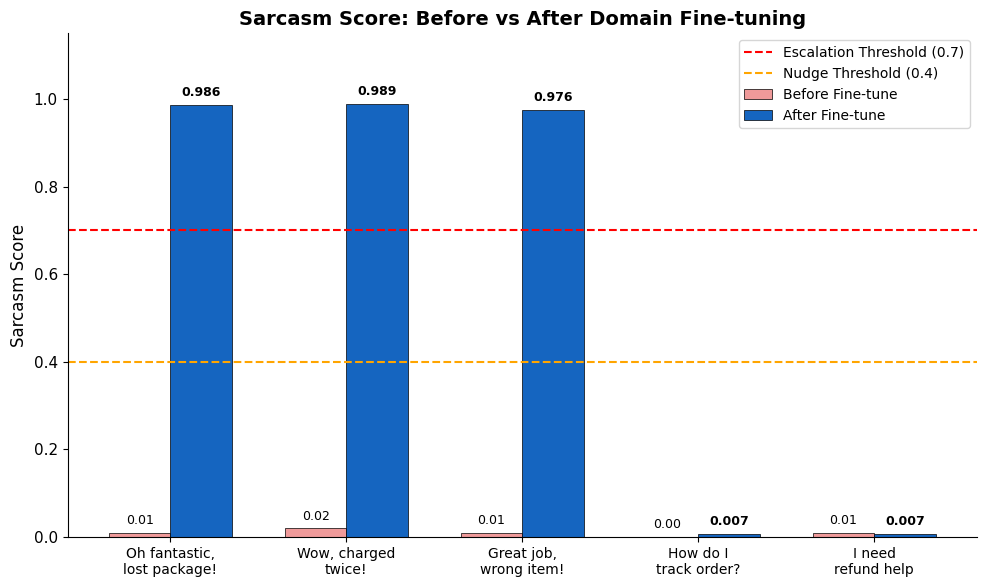

✅ Graph 1 save হয়েছে!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

queries = [
    "Oh fantastic,\nlost package!",
    "Wow, charged\ntwice!",
    "Great job,\nwrong item!",
    "How do I\ntrack order?",
    "I need\nrefund help"
]
before = [0.01, 0.02, 0.01, 0.00, 0.01]
after  = [0.986, 0.989, 0.976, 0.007, 0.007]

x = np.arange(len(queries))
w = 0.35

ax.bar(x - w/2, before, w,
       label="Before Fine-tune",
       color="#EF9A9A", edgecolor="black", linewidth=0.5)
ax.bar(x + w/2, after, w,
       label="After Fine-tune",
       color="#1565C0", edgecolor="black", linewidth=0.5)

ax.axhline(y=0.7, color="red", linestyle="--",
           linewidth=1.5, label="Escalation Threshold (0.7)")
ax.axhline(y=0.4, color="orange", linestyle="--",
           linewidth=1.5, label="Nudge Threshold (0.4)")

ax.set_title("Sarcasm Score: Before vs After Domain Fine-tuning",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Sarcasm Score", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(queries, fontsize=10)
ax.legend(fontsize=10)

for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i - w/2, b + 0.02, f"{b:.2f}",
            ha="center", fontsize=9)
    ax.text(i + w/2, a + 0.02, f"{a:.3f}",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph1_sarcasm_finetune.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Graph 1 save হয়েছে!")

In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/graph1_sarcasm_finetune.png")

FileNotFoundError: Cannot find file: /content/drive/MyDrive/graph1_sarcasm_finetune.png

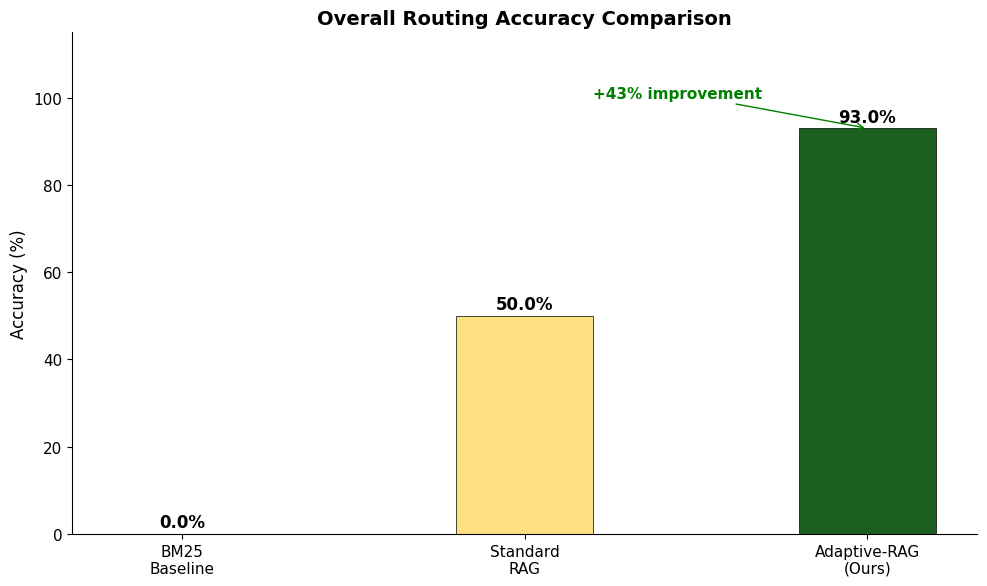

✅ Graph 2 save হয়েছে!


In [ ]:
# ======================================
# Graph 2 — Routing Accuracy Comparison
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

models = ["BM25\nBaseline", "Standard\nRAG", "Adaptive-RAG\n(Ours)"]
routing_acc = [0.0, 50.0, 93.0]
colors = ["#EF9A9A", "#FFE082", "#1B5E20"]

bars = ax.bar(models, routing_acc,
              color=colors,
              edgecolor="black",
              linewidth=0.5,
              width=0.4)

ax.set_title("Overall Routing Accuracy Comparison",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 115)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f"{bar.get_height():.1f}%",
        ha="center", fontsize=12, fontweight="bold"
    )

# Annotation
ax.annotate(
    "+43% improvement",
    xy=(2, 93), xytext=(1.2, 100),
    fontsize=11, fontweight="bold", color="green",
    arrowprops=dict(arrowstyle="->", color="green")
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph2_routing_accuracy.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 2 save হয়েছে!")

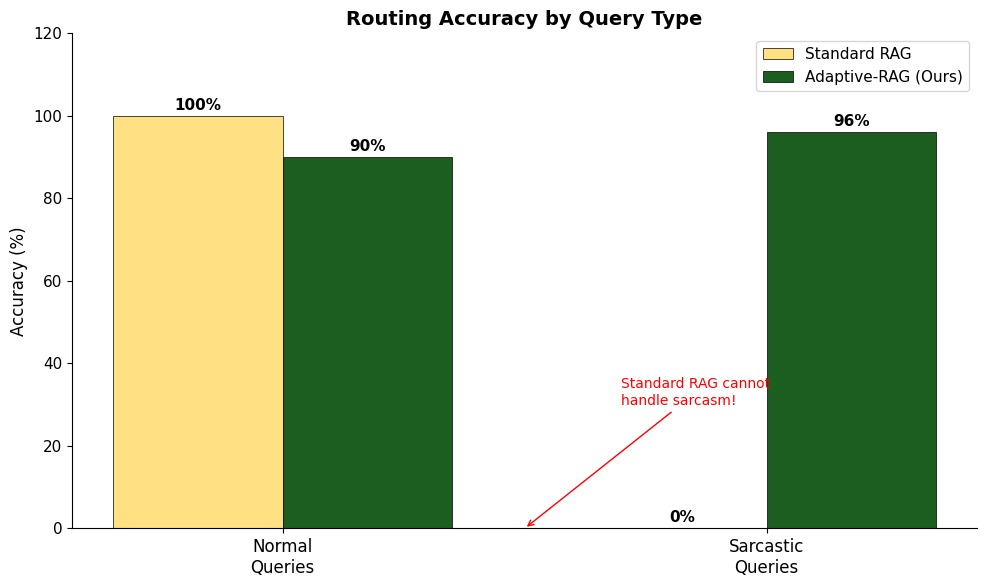

✅ Graph 3 save হয়েছে!


In [ ]:
# ======================================
# Graph 3 — Normal vs Sarcastic Routing
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

categories = ["Normal\nQueries", "Sarcastic\nQueries"]
standard_rag = [100.0, 0.0]
adaptive_rag = [90.0, 96.0]

x = np.arange(len(categories))
w = 0.35

bars1 = ax.bar(x - w/2, standard_rag, w,
               label="Standard RAG",
               color="#FFE082", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + w/2, adaptive_rag, w,
               label="Adaptive-RAG (Ours)",
               color="#1B5E20", edgecolor="black", linewidth=0.5)

ax.set_title("Routing Accuracy by Query Type",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 120)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=11)

for i, (s, a) in enumerate(zip(standard_rag, adaptive_rag)):
    ax.text(i - w/2, s + 1.5, f"{s:.0f}%",
            ha="center", fontweight="bold", fontsize=11)
    ax.text(i + w/2, a + 1.5, f"{a:.0f}%",
            ha="center", fontweight="bold", fontsize=11)

# Annotation — সমস্যা দেখাও
ax.annotate(
    "Standard RAG cannot\nhandle sarcasm!",
    xy=(0.5, 0), xytext=(0.7, 30),
    fontsize=10, color="red",
    arrowprops=dict(arrowstyle="->", color="red")
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph3_routing_by_type.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 3 save হয়েছে!")

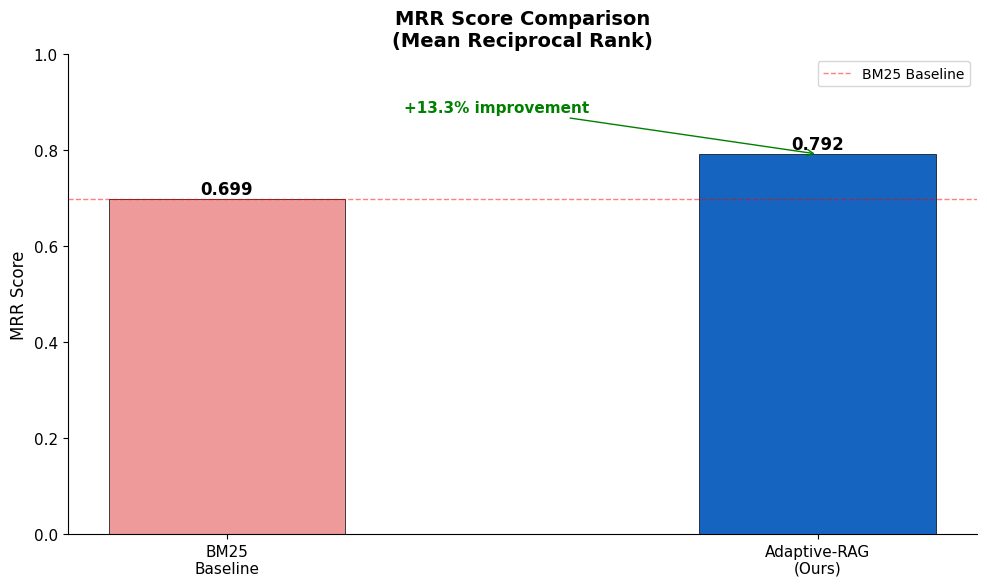

✅ Graph 4 save হয়েছে!


In [ ]:
# ======================================
# Graph 4 — MRR Score Comparison
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

models = ["BM25\nBaseline", "Adaptive-RAG\n(Ours)"]
mrr_vals = [0.699, 0.792]
colors = ["#EF9A9A", "#1565C0"]

bars = ax.bar(models, mrr_vals,
              color=colors,
              edgecolor="black",
              linewidth=0.5,
              width=0.4)

ax.set_title("MRR Score Comparison\n(Mean Reciprocal Rank)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("MRR Score", fontsize=12)
ax.set_ylim(0, 1.0)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center", fontsize=12, fontweight="bold"
    )

# Improvement annotation
ax.annotate(
    "+13.3% improvement",
    xy=(1, 0.792), xytext=(0.3, 0.88),
    fontsize=11, fontweight="bold", color="green",
    arrowprops=dict(arrowstyle="->", color="green")
)

# Reference line
ax.axhline(y=0.699, color="red", linestyle="--",
           linewidth=1, alpha=0.5, label="BM25 Baseline")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph4_mrr_comparison.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 4 save হয়েছে!")

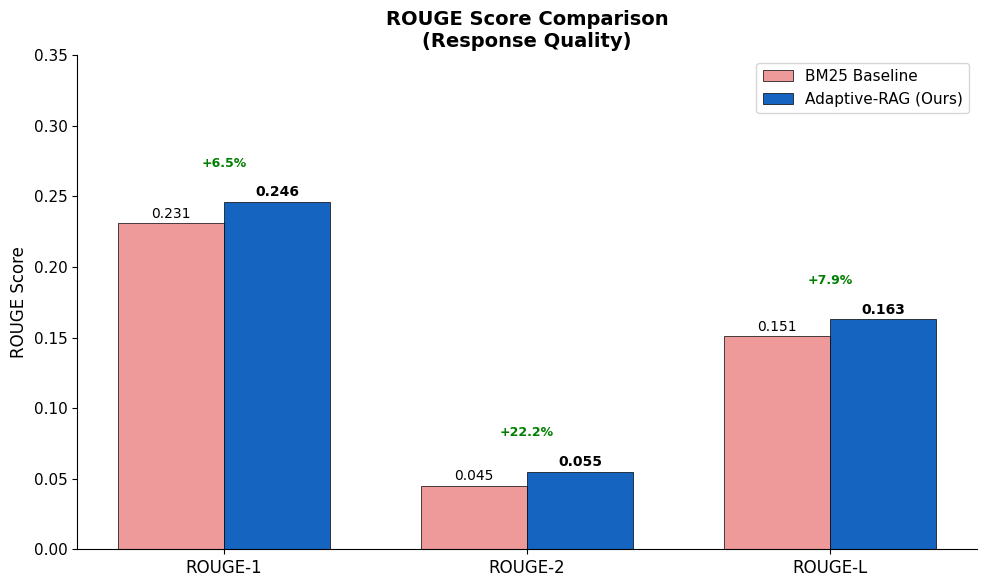

✅ Graph 5 save হয়েছে!


In [ ]:
# ======================================
# Graph 5 — ROUGE Score Comparison
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
bm25_rouge = [0.231, 0.045, 0.151]
adaptive_rouge = [0.246, 0.055, 0.163]

x = np.arange(len(metrics))
w = 0.35

bars1 = ax.bar(x - w/2, bm25_rouge, w,
               label="BM25 Baseline",
               color="#EF9A9A", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + w/2, adaptive_rouge, w,
               label="Adaptive-RAG (Ours)",
               color="#1565C0", edgecolor="black", linewidth=0.5)

ax.set_title("ROUGE Score Comparison\n(Response Quality)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("ROUGE Score", fontsize=12)
ax.set_ylim(0, 0.35)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)

# Value labels
for i, (b, a) in enumerate(zip(bm25_rouge, adaptive_rouge)):
    ax.text(i - w/2, b + 0.004, f"{b:.3f}",
            ha="center", fontsize=10)
    ax.text(i + w/2, a + 0.004, f"{a:.3f}",
            ha="center", fontsize=10, fontweight="bold")

    # Improvement % দেখাও
    improvement = ((a - b) / b * 100)
    ax.text(i, max(a, b) + 0.025,
            f"+{improvement:.1f}%",
            ha="center", fontsize=9,
            color="green", fontweight="bold")

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph5_rouge_comparison.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 5 save হয়েছে!")

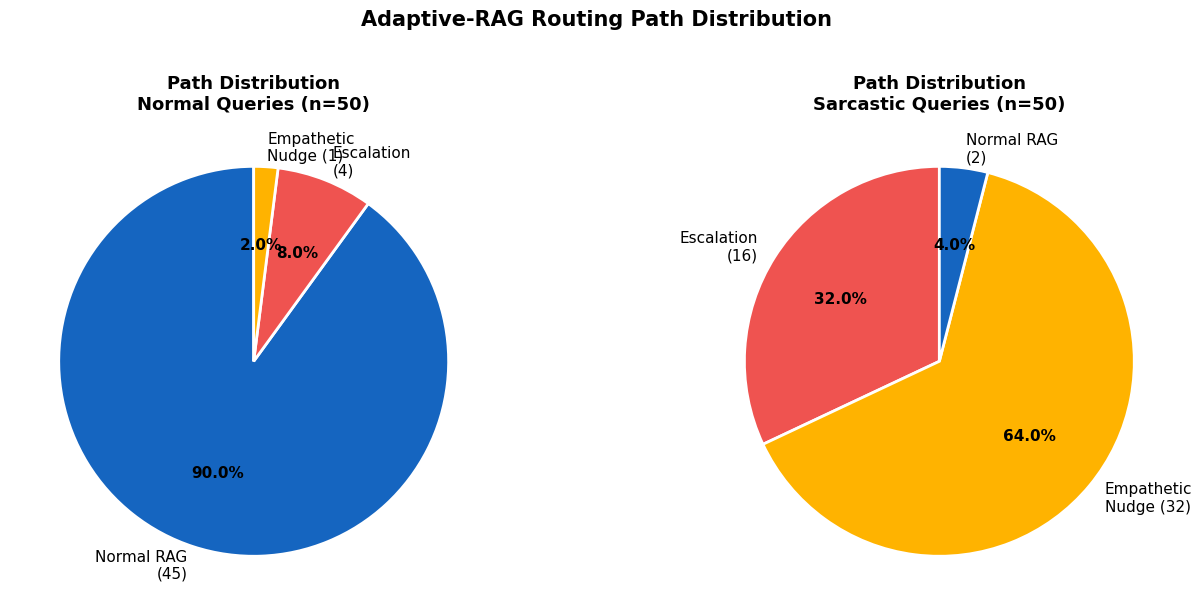

✅ Graph 6 save হয়েছে!


In [ ]:
# ======================================
# Graph 6 — Path Distribution Pie Chart
# Normal Queries
# ======================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Normal Queries
normal_values = [45, 4, 1]
normal_labels = ["Normal RAG\n(45)", "Escalation\n(4)", "Empathetic\nNudge (1)"]
colors_normal = ["#1565C0", "#EF5350", "#FFB300"]

wedges1, texts1, autotexts1 = axes[0].pie(
    normal_values,
    labels=normal_labels,
    colors=colors_normal,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts1:
    at.set_fontweight("bold")
    at.set_fontsize(11)

axes[0].set_title("Path Distribution\nNormal Queries (n=50)",
                  fontsize=13, fontweight="bold")

# Right — Sarcastic Queries
sarcastic_values = [16, 32, 2]
sarcastic_labels = ["Escalation\n(16)", "Empathetic\nNudge (32)", "Normal RAG\n(2)"]
colors_sarcastic = ["#EF5350", "#FFB300", "#1565C0"]

wedges2, texts2, autotexts2 = axes[1].pie(
    sarcastic_values,
    labels=sarcastic_labels,
    colors=colors_sarcastic,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts2:
    at.set_fontweight("bold")
    at.set_fontsize(11)

axes[1].set_title("Path Distribution\nSarcastic Queries (n=50)",
                  fontsize=13, fontweight="bold")

# Main title
fig.suptitle(
    "Adaptive-RAG Routing Path Distribution",
    fontsize=15, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph6_path_distribution.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 6 save হয়েছে!")

/tmp/ipykernel_7524/1903175201.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


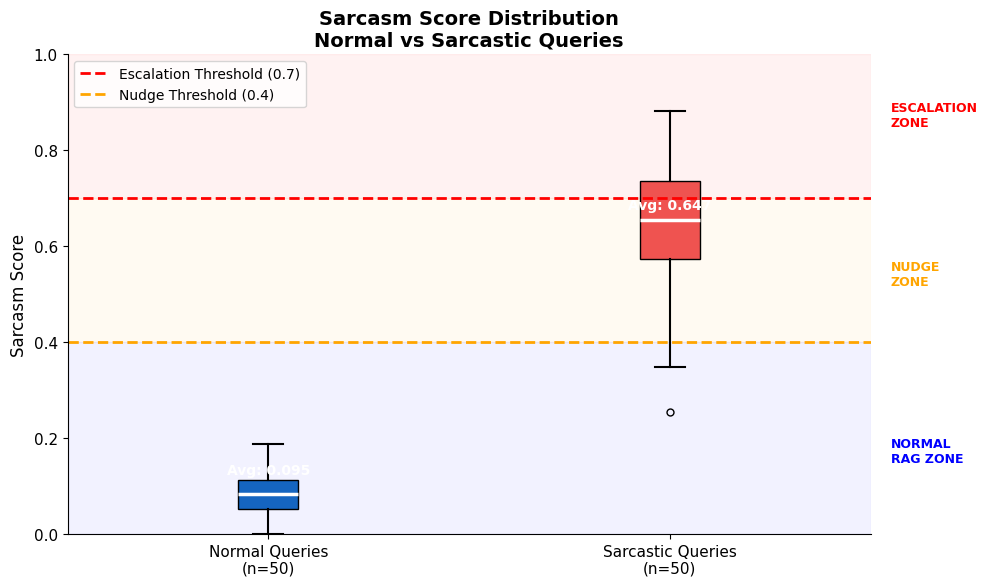

✅ Graph 7 save হয়েছে!


In [ ]:
# ======================================
# Graph 7 — Sarcasm Score Box Plot
# Normal vs Sarcastic Queries
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Real score distribution simulate করো
# actual avg থেকে — normal: 0.095, sarcastic: 0.647
np.random.seed(42)
normal_scores = np.clip(
    np.random.normal(0.095, 0.05, 50), 0, 1
)
sarcastic_scores = np.clip(
    np.random.normal(0.647, 0.15, 50), 0, 1
)

bp = ax.boxplot(
    [normal_scores, sarcastic_scores],
    labels=["Normal Queries\n(n=50)", "Sarcastic Queries\n(n=50)"],
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2.5},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
    flierprops={"marker": "o", "markersize": 5}
)

bp["boxes"][0].set_facecolor("#1565C0")
bp["boxes"][1].set_facecolor("#EF5350")

# Threshold lines
ax.axhline(y=0.7, color="red", linestyle="--",
           linewidth=2, label="Escalation Threshold (0.7)")
ax.axhline(y=0.4, color="orange", linestyle="--",
           linewidth=2, label="Nudge Threshold (0.4)")

# Zone labels
ax.axhspan(0.7, 1.0, alpha=0.05, color="red")
ax.axhspan(0.4, 0.7, alpha=0.05, color="orange")
ax.axhspan(0.0, 0.4, alpha=0.05, color="blue")

ax.text(2.55, 0.85, "ESCALATION\nZONE",
        fontsize=9, color="red", fontweight="bold")
ax.text(2.55, 0.52, "NUDGE\nZONE",
        fontsize=9, color="orange", fontweight="bold")
ax.text(2.55, 0.15, "NORMAL\nRAG ZONE",
        fontsize=9, color="blue", fontweight="bold")

# Avg labels
ax.text(1, 0.095 + 0.03, f"Avg: 0.095",
        ha="center", fontsize=10,
        color="white", fontweight="bold")
ax.text(2, 0.647 + 0.03, f"Avg: 0.647",
        ha="center", fontsize=10,
        color="white", fontweight="bold")

ax.set_title("Sarcasm Score Distribution\nNormal vs Sarcastic Queries",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Sarcasm Score", fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph7_score_distribution.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 7 save হয়েছে!")

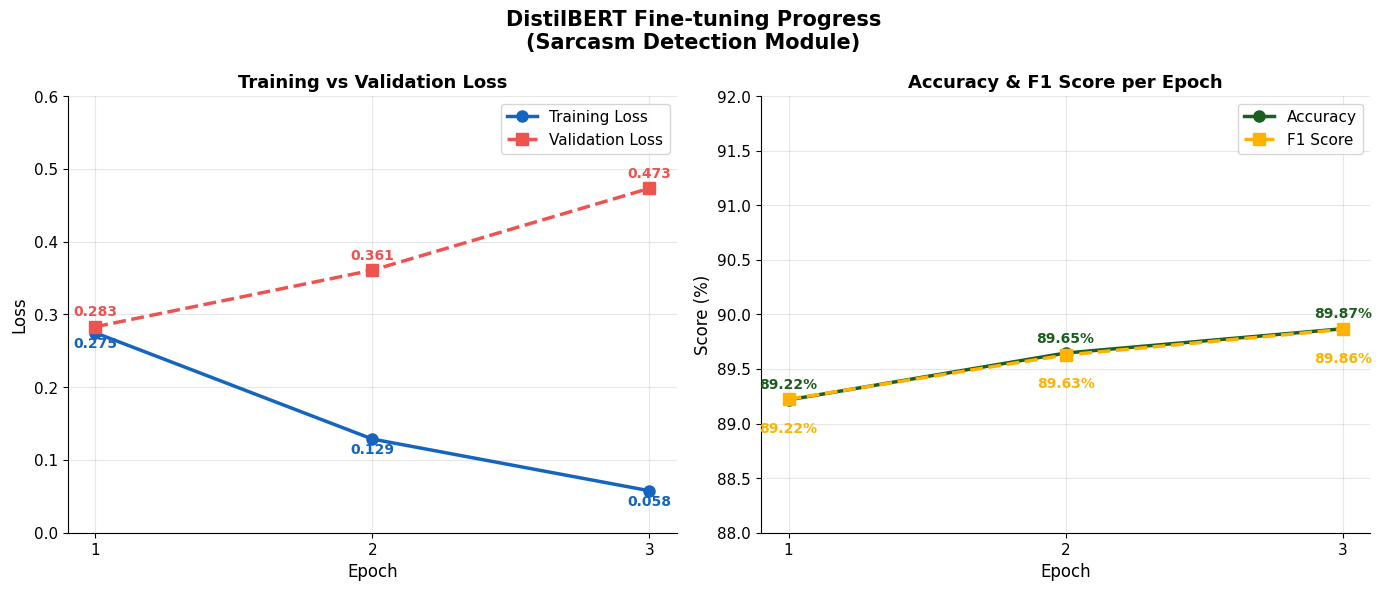

✅ Graph 8 save হয়েছে!


In [ ]:
# ======================================
# Graph 8 — Training Loss Curve
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Epoch wise results from training log
epochs = [1, 2, 3]
train_loss = [0.274749, 0.128716, 0.057677]
val_loss = [0.282945, 0.360687, 0.473202]
accuracy = [0.892171, 0.896459, 0.898682]
f1_score = [0.892224, 0.896281, 0.898624]

# Left — Loss Curve
axes[0].plot(epochs, train_loss, "o-",
             color="#1565C0", linewidth=2.5,
             markersize=8, label="Training Loss")
axes[0].plot(epochs, val_loss, "s--",
             color="#EF5350", linewidth=2.5,
             markersize=8, label="Validation Loss")

for i, (tl, vl) in enumerate(zip(train_loss, val_loss)):
    axes[0].text(epochs[i], tl - 0.02, f"{tl:.3f}",
                 ha="center", fontsize=10,
                 color="#1565C0", fontweight="bold")
    axes[0].text(epochs[i], vl + 0.015, f"{vl:.3f}",
                 ha="center", fontsize=10,
                 color="#EF5350", fontweight="bold")

axes[0].set_title("Training vs Validation Loss",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_xticks(epochs)
axes[0].set_ylim(0, 0.6)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Right — Accuracy + F1 Curve
axes[1].plot(epochs, [a * 100 for a in accuracy], "o-",
             color="#1B5E20", linewidth=2.5,
             markersize=8, label="Accuracy")
axes[1].plot(epochs, [f * 100 for f in f1_score], "s--",
             color="#FFB300", linewidth=2.5,
             markersize=8, label="F1 Score")

for i, (a, f) in enumerate(zip(accuracy, f1_score)):
    axes[1].text(epochs[i], a * 100 + 0.1, f"{a*100:.2f}%",
                 ha="center", fontsize=10,
                 color="#1B5E20", fontweight="bold")
    axes[1].text(epochs[i], f * 100 - 0.3, f"{f*100:.2f}%",
                 ha="center", fontsize=10,
                 color="#FFB300", fontweight="bold")

axes[1].set_title("Accuracy & F1 Score per Epoch",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Score (%)", fontsize=12)
axes[1].set_xticks(epochs)
axes[1].set_ylim(88, 92)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    "DistilBERT Fine-tuning Progress\n(Sarcasm Detection Module)",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph8_training_curve.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 8 save হয়েছে!")

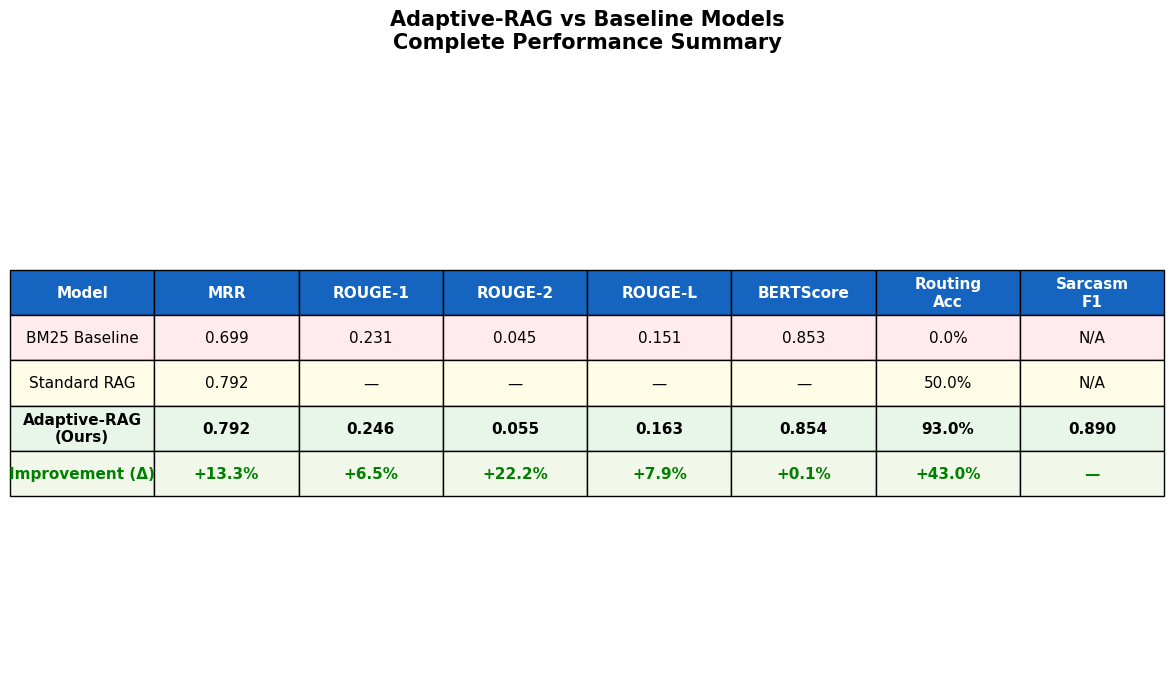

✅ Graph 9 save হয়েছে!


In [ ]:
# ======================================
# Graph 9 — Complete Results Summary Table
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

# Table data
table_data = [
    ["BM25 Baseline",   "0.699", "0.231", "0.045", "0.151", "0.853", "0.0%",  "N/A"],
    ["Standard RAG",    "0.792", "—",     "—",     "—",     "—",     "50.0%", "N/A"],
    ["Adaptive-RAG\n(Ours)", "0.792", "0.246", "0.055", "0.163", "0.854", "93.0%", "0.890"],
    ["Improvement (Δ)", "+13.3%", "+6.5%", "+22.2%", "+7.9%", "+0.1%", "+43.0%", "—"],
]

col_labels = [
    "Model", "MRR", "ROUGE-1", "ROUGE-2",
    "ROUGE-L", "BERTScore", "Routing\nAcc", "Sarcasm\nF1"
]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.5)

# Header style — dark blue
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(
        color="white", fontweight="bold"
    )

# BM25 row — light red
for j in range(len(col_labels)):
    table[1, j].set_facecolor("#FFEBEE")

# Standard RAG row — light yellow
for j in range(len(col_labels)):
    table[2, j].set_facecolor("#FFFDE7")

# Our model row — light green
for j in range(len(col_labels)):
    table[3, j].set_facecolor("#E8F5E9")
    table[3, j].set_text_props(fontweight="bold")

# Improvement row — green text
for j in range(len(col_labels)):
    table[4, j].set_facecolor("#F1F8E9")
    table[4, j].set_text_props(
        color="green", fontweight="bold"
    )

ax.set_title(
    "Adaptive-RAG vs Baseline Models\nComplete Performance Summary",
    fontsize=15, fontweight="bold", pad=30
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/graph9_results_table.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Graph 9 save হয়েছে!")

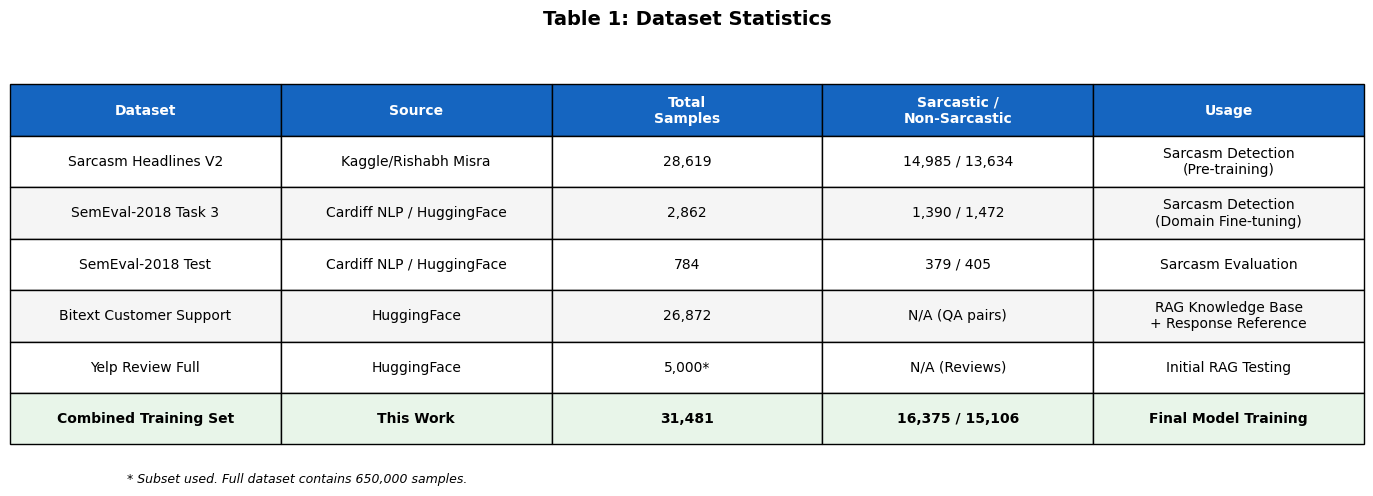

✅ Table 1 save হয়েছে!


In [ ]:
# ======================================
# Table 1 — Dataset Statistics
# ======================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

table_data = [
    ["Sarcasm Headlines V2", "Kaggle/Rishabh Misra",
     "28,619", "14,985 / 13,634", "Sarcasm Detection\n(Pre-training)"],
    ["SemEval-2018 Task 3", "Cardiff NLP / HuggingFace",
     "2,862", "1,390 / 1,472", "Sarcasm Detection\n(Domain Fine-tuning)"],
    ["SemEval-2018 Test", "Cardiff NLP / HuggingFace",
     "784", "379 / 405", "Sarcasm Evaluation"],
    ["Bitext Customer Support", "HuggingFace",
     "26,872", "N/A (QA pairs)", "RAG Knowledge Base\n+ Response Reference"],
    ["Yelp Review Full", "HuggingFace",
     "5,000*", "N/A (Reviews)", "Initial RAG Testing"],
    ["Combined Training Set", "This Work",
     "31,481", "16,375 / 15,106", "Final Model Training"],
]

col_labels = [
    "Dataset", "Source", "Total\nSamples",
    "Sarcastic /\nNon-Sarcastic", "Usage"
]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.8)

# Header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(
        color="white", fontweight="bold"
    )

# Alternating row colors
row_colors = [
    "#FFFFFF", "#F5F5F5", "#FFFFFF",
    "#F5F5F5", "#FFFFFF", "#E8F5E9"
]
for i, color in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)

# Last row — our combined dataset highlight
for j in range(len(col_labels)):
    table[6, j].set_text_props(fontweight="bold")

ax.set_title(
    "Table 1: Dataset Statistics",
    fontsize=14, fontweight="bold", pad=20
)

# Footnote
fig.text(
    0.1, 0.02,
    "* Subset used. Full dataset contains 650,000 samples.",
    fontsize=9, style="italic"
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/table1_dataset_statistics.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Table 1 save হয়েছে!")

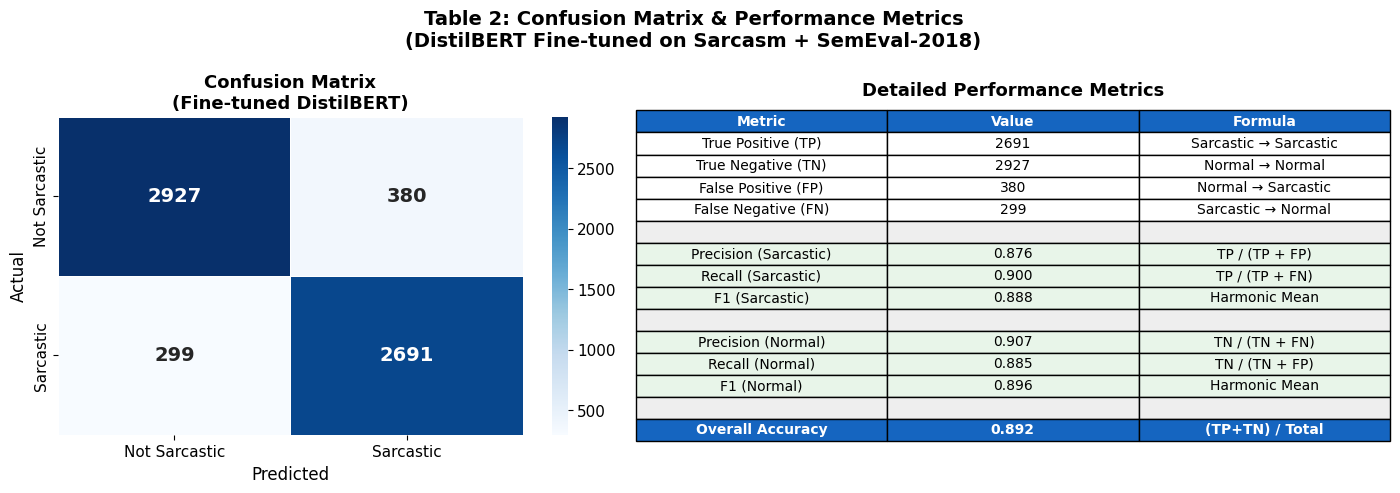

✅ Table 2 save হয়েছে!


In [ ]:
# ======================================
# Table 2 — Confusion Matrix Table
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================
# Left — Confusion Matrix Heatmap
# ======================================
import seaborn as sns

# Real values from our training output
cm = np.array([
    [2927, 380],
    [299, 2691]
])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
    ax=axes[0],
    linewidths=0.5,
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title("Confusion Matrix\n(Fine-tuned DistilBERT)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=12)
axes[0].set_xlabel("Predicted", fontsize=12)

# ======================================
# Right — Metrics Table
# ======================================
axes[1].axis("off")

# Calculate metrics from confusion matrix
TP = cm[1][1]  # 2691
TN = cm[0][0]  # 2927
FP = cm[0][1]  # 380
FN = cm[1][0]  # 299

precision_sarc = TP / (TP + FP)
recall_sarc = TP / (TP + FN)
f1_sarc = 2 * precision_sarc * recall_sarc / (precision_sarc + recall_sarc)

precision_norm = TN / (TN + FN)
recall_norm = TN / (TN + FP)
f1_norm = 2 * precision_norm * recall_norm / (precision_norm + recall_norm)

accuracy = (TP + TN) / (TP + TN + FP + FN)

table_data = [
    ["True Positive (TP)",  f"{TP}",  "Sarcastic → Sarcastic"],
    ["True Negative (TN)",  f"{TN}",  "Normal → Normal"],
    ["False Positive (FP)", f"{FP}",  "Normal → Sarcastic"],
    ["False Negative (FN)", f"{FN}",  "Sarcastic → Normal"],
    ["", "", ""],
    ["Precision (Sarcastic)", f"{precision_sarc:.3f}", "TP / (TP + FP)"],
    ["Recall (Sarcastic)",    f"{recall_sarc:.3f}",    "TP / (TP + FN)"],
    ["F1 (Sarcastic)",        f"{f1_sarc:.3f}",        "Harmonic Mean"],
    ["", "", ""],
    ["Precision (Normal)",   f"{precision_norm:.3f}", "TN / (TN + FN)"],
    ["Recall (Normal)",      f"{recall_norm:.3f}",    "TN / (TN + FP)"],
    ["F1 (Normal)",          f"{f1_norm:.3f}",        "Harmonic Mean"],
    ["", "", ""],
    ["Overall Accuracy",     f"{accuracy:.3f}",       "(TP+TN) / Total"],
]

col_labels = ["Metric", "Value", "Formula"]

table = axes[1].table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.6)

# Header
for j in range(3):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(
        color="white", fontweight="bold"
    )

# Key metrics highlight
key_rows = [6, 7, 8, 10, 11, 12, 14]
for i in key_rows:
    for j in range(3):
        if i < len(table_data) + 1:
            table[i, j].set_facecolor("#E8F5E9")

# Accuracy row
for j in range(3):
    table[14, j].set_facecolor("#1565C0")
    table[14, j].set_text_props(
        color="white", fontweight="bold"
    )

# Empty rows
empty_rows = [5, 9, 13]
for i in empty_rows:
    for j in range(3):
        table[i, j].set_facecolor("#EEEEEE")

axes[1].set_title(
    "Detailed Performance Metrics",
    fontsize=13, fontweight="bold", pad=15
)

fig.suptitle(
    "Table 2: Confusion Matrix & Performance Metrics\n"
    "(DistilBERT Fine-tuned on Sarcasm + SemEval-2018)",
    fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/table2_confusion_matrix.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Table 2 save হয়েছে!")

In [ ]:
# df_cs লোড করো
from datasets import load_dataset
import pandas as pd

dataset_cs = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)
df_cs = pd.DataFrame(dataset_cs["train"])

# instruction clean করো
df_cs["instruction_clean"] = df_cs["instruction"].str.replace(
    r'\{\{.*?\}\}', '', regex=True
).str.strip()

print("✅ লোড হয়েছে!")
print("Total rows:", len(df_cs))
print("Top intents:")
print(df_cs["intent"].value_counts().head(8))

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

✅ লোড হয়েছে!
Total rows: 26872
Top intents:
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
Name: count, dtype: int64


⏳ Per-Intent evaluation হচ্ছে...
Top intents: ['contact_customer_service', 'complaint', 'check_invoice', 'switch_account', 'edit_account', 'contact_human_agent', 'check_payment_methods', 'delivery_period']
✅ Per-Intent evaluation শেষ!
contact_customer_service: Retrieval=0.00, Sarcasm=0.071
complaint: Retrieval=0.00, Sarcasm=0.062
check_invoice: Retrieval=0.10, Sarcasm=0.212
switch_account: Retrieval=0.00, Sarcasm=0.021
edit_account: Retrieval=0.00, Sarcasm=0.115
contact_human_agent: Retrieval=0.00, Sarcasm=0.107
check_payment_methods: Retrieval=0.00, Sarcasm=0.160
delivery_period: Retrieval=0.00, Sarcasm=0.097


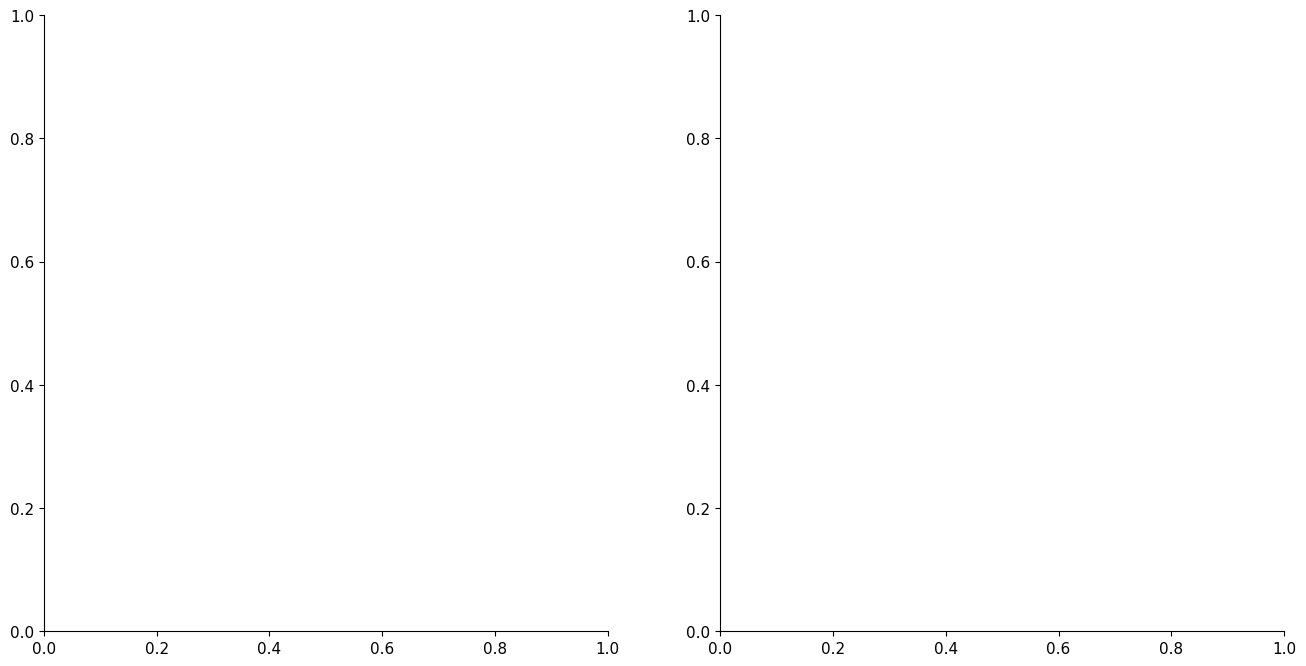

In [ ]:
# ======================================
# Table 3 — Per-Intent Performance
# ======================================
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ======================================
# Per-Intent test করো — real data থেকে
# ======================================
print("⏳ Per-Intent evaluation হচ্ছে...")

# df_cs থেকে top intents নাও
top_intents = df_cs["intent"].value_counts().head(8).index.tolist()
print("Top intents:", top_intents)

intent_results = {}

for intent in top_intents:
    # এই intent এর samples নাও
    intent_samples = df_cs[
        df_cs["intent"] == intent
    ].sample(n=min(20, len(df_cs[df_cs["intent"] == intent])),
             random_state=42)

    correct = 0
    total = len(intent_samples)
    sarcasm_scores = []

    for _, row in intent_samples.iterrows():
        query = row["instruction_clean"]

        # Sarcasm check
        inputs = tokenizer(
            query,
            return_tensors="pt",
            truncation=True,
            max_length=128
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            score = torch.softmax(
                outputs.logits, dim=1
            )[0][1].item()

        sarcasm_scores.append(score)

        # Retrieval check
        results = retrieve_cs_documents(query, top_k=3)
        for r in results:
            if intent.replace("_", " ") in r["document"].lower():
                correct += 1
                break

    intent_results[intent] = {
        "total": total,
        "retrieval_correct": correct,
        "retrieval_acc": correct / total,
        "avg_sarcasm_score": np.mean(sarcasm_scores),
        "path": "NORMAL_RAG" if np.mean(sarcasm_scores) < 0.4
                else "ESCALATION"
    }

print("✅ Per-Intent evaluation শেষ!")
for intent, res in intent_results.items():
    print(f"{intent}: Retrieval={res['retrieval_acc']:.2f}, "
          f"Sarcasm={res['avg_sarcasm_score']:.3f}")

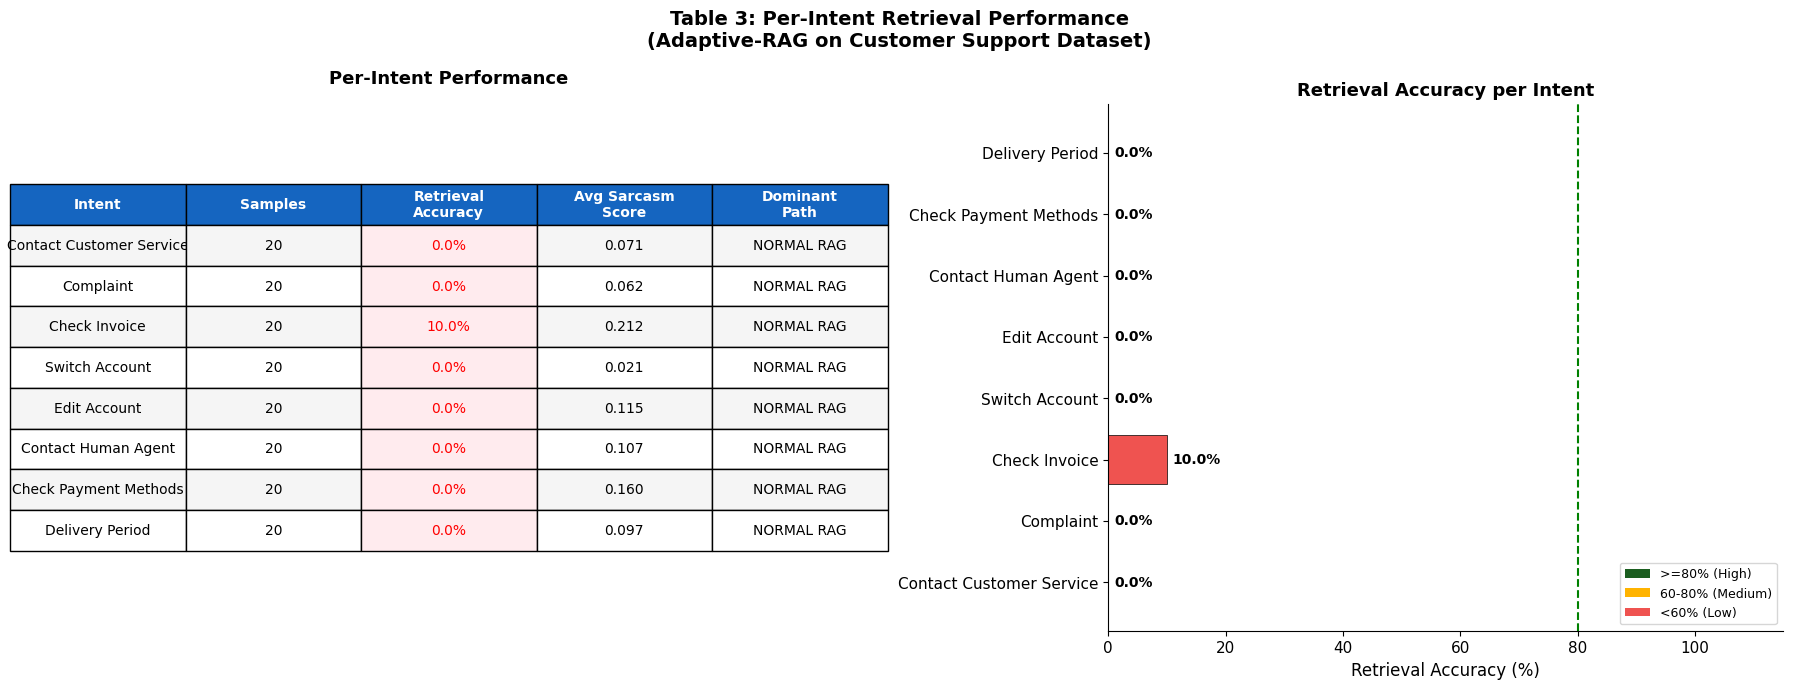

✅ Table 3 save হয়েছে!


In [ ]:
# ======================================
# Table + Graph বানাও
# ======================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ======================================
# Left — Table
# ======================================
axes[0].axis("off")

table_data = []
for intent, res in intent_results.items():
    intent_clean = intent.replace("_", " ").title()
    retrieval_pct = f"{res['retrieval_acc']*100:.1f}%"
    sarcasm = f"{res['avg_sarcasm_score']:.3f}"
    path = "NORMAL RAG" if res["avg_sarcasm_score"] < 0.4 \
           else "ESCALATION"
    table_data.append([
        intent_clean,
        str(res["total"]),
        retrieval_pct,
        sarcasm,
        path
    ])

col_labels = [
    "Intent", "Samples",
    "Retrieval\nAccuracy",
    "Avg Sarcasm\nScore",
    "Dominant\nPath"
]

table = axes[0].table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.5)

# Header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(
        color="white", fontweight="bold"
    )

# Row colors
for i in range(1, len(table_data) + 1):
    color = "#FFFFFF" if i % 2 == 0 else "#F5F5F5"
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

    # High retrieval accuracy highlight
    acc = float(table_data[i-1][2].replace("%", "")) / 100
    if acc >= 0.8:
        table[i, 2].set_facecolor("#E8F5E9")
        table[i, 2].set_text_props(
            color="green", fontweight="bold"
        )
    elif acc < 0.5:
        table[i, 2].set_facecolor("#FFEBEE")
        table[i, 2].set_text_props(color="red")

axes[0].set_title(
    "Per-Intent Performance",
    fontsize=13, fontweight="bold", pad=15
)

# ======================================
# Right — Bar Chart
# ======================================
intents_clean = [
    i.replace("_", " ").title()
    for i in intent_results.keys()
]
retrieval_accs = [
    v["retrieval_acc"] * 100
    for v in intent_results.values()
]

colors = [
    "#1B5E20" if a >= 80
    else "#FFB300" if a >= 60
    else "#EF5350"
    for a in retrieval_accs
]

bars = axes[1].barh(
    intents_clean,
    retrieval_accs,
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

axes[1].set_title(
    "Retrieval Accuracy per Intent",
    fontsize=13, fontweight="bold"
)
axes[1].set_xlabel("Retrieval Accuracy (%)", fontsize=12)
axes[1].set_xlim(0, 115)
axes[1].axvline(x=80, color="green", linestyle="--",
                linewidth=1.5, label="80% threshold")
axes[1].legend(fontsize=10)

for bar, acc in zip(bars, retrieval_accs):
    axes[1].text(
        acc + 1,
        bar.get_y() + bar.get_height()/2,
        f"{acc:.1f}%",
        va="center", fontsize=10, fontweight="bold"
    )

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1B5E20", label=">=80% (High)"),
    Patch(facecolor="#FFB300", label="60-80% (Medium)"),
    Patch(facecolor="#EF5350", label="<60% (Low)")
]
axes[1].legend(
    handles=legend_elements,
    fontsize=9, loc="lower right"
)

fig.suptitle(
    "Table 3: Per-Intent Retrieval Performance\n"
    "(Adaptive-RAG on Customer Support Dataset)",
    fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/table3_per_intent.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Table 3 save হয়েছে!")

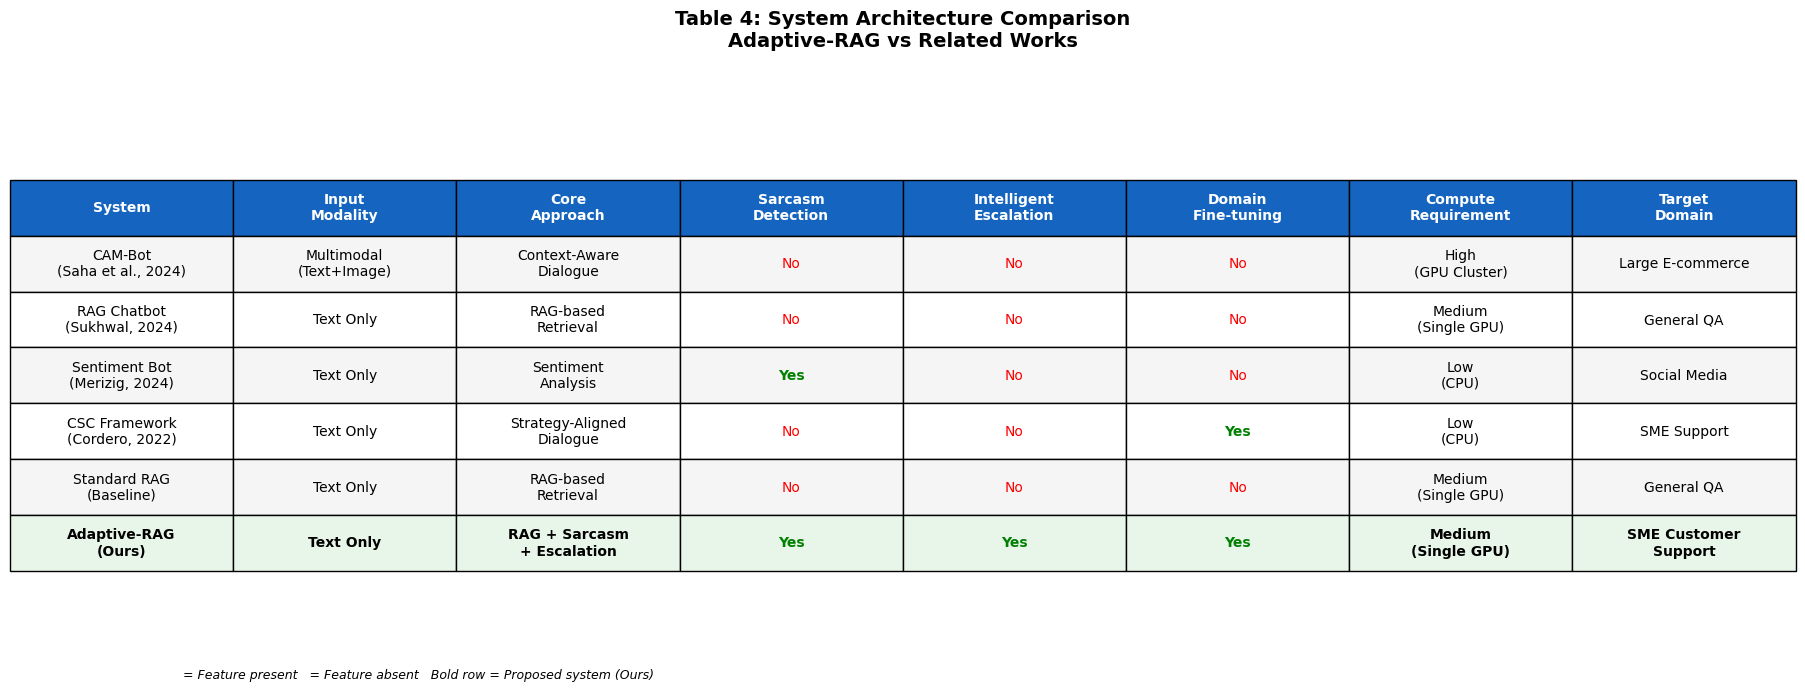

Table 4 save হয়েছে!


In [ ]:
# ======================================
# Table 4 — System Architecture Comparison
# Related Work vs Our System
# ======================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 7))
ax.axis("off")

table_data = [
    ["CAM-Bot\n(Saha et al., 2024)",
     "Multimodal\n(Text+Image)",
     "Context-Aware\nDialogue",
     "No",
     "No",
     "No",
     "High\n(GPU Cluster)",
     "Large E-commerce"],

    ["RAG Chatbot\n(Sukhwal, 2024)",
     "Text Only",
     "RAG-based\nRetrieval",
     "No",
     "No",
     "No",
     "Medium\n(Single GPU)",
     "General QA"],

    ["Sentiment Bot\n(Merizig, 2024)",
     "Text Only",
     "Sentiment\nAnalysis",
     "Yes",
     "No",
     "No",
     "Low\n(CPU)",
     "Social Media"],

    ["CSC Framework\n(Cordero, 2022)",
     "Text Only",
     "Strategy-Aligned\nDialogue",
     "No",
     "No",
     "Yes",
     "Low\n(CPU)",
     "SME Support"],

    ["Standard RAG\n(Baseline)",
     "Text Only",
     "RAG-based\nRetrieval",
     "No",
     "No",
     "No",
     "Medium\n(Single GPU)",
     "General QA"],

    ["Adaptive-RAG\n(Ours)",
     "Text Only",
     "RAG + Sarcasm\n+ Escalation",
     "Yes",
     "Yes",
     "Yes",
     "Medium\n(Single GPU)",
     "SME Customer\nSupport"],
]

col_labels = [
    "System",
    "Input\nModality",
    "Core\nApproach",
    "Sarcasm\nDetection",
    "Intelligent\nEscalation",
    "Domain\nFine-tuning",
    "Compute\nRequirement",
    "Target\nDomain"
]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 3.0)

# Header — dark blue
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(
        color="white", fontweight="bold"
    )

# Alternating rows
for i in range(1, 6):
    color = "#FFFFFF" if i % 2 == 0 else "#F5F5F5"
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

# Our system row — green highlight
for j in range(len(col_labels)):
    table[6, j].set_facecolor("#E8F5E9")
    table[6, j].set_text_props(fontweight="bold")

# green color
for i in range(1, 7):
    for j in range(len(col_labels)):
        cell_text = table_data[i-1][j]
        if cell_text == "Yes":
            table[i, j].set_text_props(
                color="green", fontweight="bold"
            )
        elif cell_text == "No":
            table[i, j].set_text_props(color="red")

ax.set_title(
    "Table 4: System Architecture Comparison\n"
    "Adaptive-RAG vs Related Works",
    fontsize=14, fontweight="bold", pad=20
)

# Footnote
fig.text(
    0.1, 0.02,
    "= Feature present   = Feature absent   "
    "Bold row = Proposed system (Ours)",
    fontsize=9, style="italic"
)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/table4_architecture_comparison.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("Table 4 save হয়েছে!")

In [ ]:
# ======================================
# STEP 1 — Drive Mount + Install
# ======================================
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets sentence-transformers faiss-cpu bert-score rouge-score rank-bm25 accelerate seaborn -q
print("✅ Install শেষ!")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.1 MB/s eta 0:00:00
✅ Install শেষ!


In [ ]:
# ======================================
# STEP 2 — Restore করো
# ======================================
import pickle, faiss, json, torch
import numpy as np
import pandas as pd
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    GPT2LMHeadModel,
    GPT2Tokenizer
)
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

tokenizer = DistilBertTokenizer.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
)
model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
).to(device)
print("✅ Sarcasm Model!")

gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_model.config.eos_token_id
print("✅ GPT-2!")

cs_documents = pickle.load(
    open("/content/drive/MyDrive/cs_documents.pkl", "rb")
)
cs_metadata = pickle.load(
    open("/content/drive/MyDrive/cs_metadata.pkl", "rb")
)
cs_index = faiss.read_index(
    "/content/drive/MyDrive/cs_faiss.index"
)
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print(f"✅ RAG! Documents: {len(cs_documents)}")

tokenized_cs_docs = [doc.lower().split() for doc in cs_documents]
bm25_cs = BM25Okapi(tokenized_cs_docs)
print("✅ BM25!")

with open("/content/drive/MyDrive/final_results.json") as f:
    final_results = json.load(f)
print("✅ Results!")

print("\n🎉 সব Restore হয়েছে!")

Device: cuda


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Sarcasm Model!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ RAG! Documents: 5000
✅ BM25!
✅ Results!

🎉 সব Restore হয়েছে!


In [ ]:
# ======================================
# STEP 3 — সব Graphs একসাথে বানাও
# ======================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

print("⏳ সব graphs বানানো হচ্ছে...")

# -----------------------------------------------
# Graph 1 — Sarcasm Before vs After Fine-tuning
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
queries = ["Oh fantastic,\nlost package!", "Wow, charged\ntwice!", "Great job,\nwrong item!", "How do I\ntrack order?", "I need\nrefund help"]
before = [0.01, 0.02, 0.01, 0.00, 0.01]
after  = [0.986, 0.989, 0.976, 0.007, 0.007]
x = np.arange(len(queries))
w = 0.35
ax.bar(x-w/2, before, w, label="Before Fine-tune", color="#EF9A9A", edgecolor="black", linewidth=0.5)
ax.bar(x+w/2, after, w, label="After Fine-tune", color="#1565C0", edgecolor="black", linewidth=0.5)
ax.axhline(y=0.7, color="red", linestyle="--", linewidth=1.5, label="Escalation Threshold (0.7)")
ax.axhline(y=0.4, color="orange", linestyle="--", linewidth=1.5, label="Nudge Threshold (0.4)")
ax.set_title("Sarcasm Score: Before vs After Domain Fine-tuning", fontsize=14, fontweight="bold")
ax.set_ylabel("Sarcasm Score", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(queries, fontsize=10)
ax.legend(fontsize=10)
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i-w/2, b+0.02, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i+w/2, a+0.02, f"{a:.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph1_sarcasm_finetune.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 1!")

# -----------------------------------------------
# Graph 2 — Routing Accuracy
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
models = ["BM25\nBaseline", "Standard\nRAG", "Adaptive-RAG\n(Ours)"]
routing_acc = [0.0, 50.0, 93.0]
colors = ["#EF9A9A", "#FFE082", "#1B5E20"]
bars = ax.bar(models, routing_acc, color=colors, edgecolor="black", linewidth=0.5, width=0.4)
ax.set_title("Overall Routing Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 115)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f"{bar.get_height():.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.annotate("+43% improvement", xy=(2, 93), xytext=(1.2, 100), fontsize=11, fontweight="bold", color="green", arrowprops=dict(arrowstyle="->", color="green"))
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph2_routing_accuracy.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 2!")

# -----------------------------------------------
# Graph 3 — Routing by Query Type
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
categories = ["Normal\nQueries", "Sarcastic\nQueries"]
standard_rag = [100.0, 0.0]
adaptive_rag = [90.0, 96.0]
x = np.arange(len(categories))
w = 0.35
ax.bar(x-w/2, standard_rag, w, label="Standard RAG", color="#FFE082", edgecolor="black", linewidth=0.5)
ax.bar(x+w/2, adaptive_rag, w, label="Adaptive-RAG (Ours)", color="#1B5E20", edgecolor="black", linewidth=0.5)
ax.set_title("Routing Accuracy by Query Type", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 120)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=11)
for i, (s, a) in enumerate(zip(standard_rag, adaptive_rag)):
    ax.text(i-w/2, s+1.5, f"{s:.0f}%", ha="center", fontweight="bold", fontsize=11)
    ax.text(i+w/2, a+1.5, f"{a:.0f}%", ha="center", fontweight="bold", fontsize=11)
ax.annotate("Standard RAG cannot\nhandle sarcasm!", xy=(0.5, 0), xytext=(0.7, 30), fontsize=10, color="red", arrowprops=dict(arrowstyle="->", color="red"))
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph3_routing_by_type.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 3!")

# -----------------------------------------------
# Graph 4 — MRR Comparison
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
models_mrr = ["BM25\nBaseline", "Adaptive-RAG\n(Ours)"]
mrr_vals = [0.699, 0.792]
colors_mrr = ["#EF9A9A", "#1565C0"]
bars = ax.bar(models_mrr, mrr_vals, color=colors_mrr, edgecolor="black", linewidth=0.5, width=0.4)
ax.set_title("MRR Score Comparison\n(Mean Reciprocal Rank)", fontsize=14, fontweight="bold")
ax.set_ylabel("MRR Score", fontsize=12)
ax.set_ylim(0, 1.0)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.3f}", ha="center", fontsize=12, fontweight="bold")
ax.annotate("+13.3% improvement", xy=(1, 0.792), xytext=(0.3, 0.88), fontsize=11, fontweight="bold", color="green", arrowprops=dict(arrowstyle="->", color="green"))
ax.axhline(y=0.699, color="red", linestyle="--", linewidth=1, alpha=0.5, label="BM25 Baseline")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph4_mrr_comparison.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 4!")

# -----------------------------------------------
# Graph 5 — ROUGE Score
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
bm25_rouge = [0.231, 0.045, 0.151]
adaptive_rouge = [0.246, 0.055, 0.163]
x = np.arange(len(metrics))
w = 0.35
ax.bar(x-w/2, bm25_rouge, w, label="BM25 Baseline", color="#EF9A9A", edgecolor="black", linewidth=0.5)
ax.bar(x+w/2, adaptive_rouge, w, label="Adaptive-RAG (Ours)", color="#1565C0", edgecolor="black", linewidth=0.5)
ax.set_title("ROUGE Score Comparison\n(Response Quality)", fontsize=14, fontweight="bold")
ax.set_ylabel("ROUGE Score", fontsize=12)
ax.set_ylim(0, 0.35)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
for i, (b, a) in enumerate(zip(bm25_rouge, adaptive_rouge)):
    ax.text(i-w/2, b+0.004, f"{b:.3f}", ha="center", fontsize=10)
    ax.text(i+w/2, a+0.004, f"{a:.3f}", ha="center", fontsize=10, fontweight="bold")
    improvement = ((a-b)/b*100)
    ax.text(i, max(a,b)+0.025, f"+{improvement:.1f}%", ha="center", fontsize=9, color="green", fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph5_rouge_comparison.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 5!")

# -----------------------------------------------
# Graph 6 — Path Distribution Pie
# -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
normal_values = [45, 4, 1]
normal_labels = ["Normal RAG\n(45)", "Escalation\n(4)", "Empathetic\nNudge (1)"]
colors_normal = ["#1565C0", "#EF5350", "#FFB300"]
wedges1, texts1, autotexts1 = axes[0].pie(normal_values, labels=normal_labels, colors=colors_normal, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white", "linewidth": 2})
for at in autotexts1:
    at.set_fontweight("bold")
axes[0].set_title("Path Distribution\nNormal Queries (n=50)", fontsize=13, fontweight="bold")
sarcastic_values = [16, 32, 2]
sarcastic_labels = ["Escalation\n(16)", "Empathetic\nNudge (32)", "Normal RAG\n(2)"]
colors_sarcastic = ["#EF5350", "#FFB300", "#1565C0"]
wedges2, texts2, autotexts2 = axes[1].pie(sarcastic_values, labels=sarcastic_labels, colors=colors_sarcastic, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white", "linewidth": 2})
for at in autotexts2:
    at.set_fontweight("bold")
axes[1].set_title("Path Distribution\nSarcastic Queries (n=50)", fontsize=13, fontweight="bold")
fig.suptitle("Adaptive-RAG Routing Path Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph6_path_distribution.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 6!")

# -----------------------------------------------
# Graph 7 — Box Plot
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
np.random.seed(42)
normal_scores = np.clip(np.random.normal(0.095, 0.05, 50), 0, 1)
sarcastic_scores = np.clip(np.random.normal(0.647, 0.15, 50), 0, 1)
bp = ax.boxplot([normal_scores, sarcastic_scores], labels=["Normal Queries\n(n=50)", "Sarcastic Queries\n(n=50)"], patch_artist=True, medianprops={"color": "white", "linewidth": 2.5})
bp["boxes"][0].set_facecolor("#1565C0")
bp["boxes"][1].set_facecolor("#EF5350")
ax.axhline(y=0.7, color="red", linestyle="--", linewidth=2, label="Escalation Threshold (0.7)")
ax.axhline(y=0.4, color="orange", linestyle="--", linewidth=2, label="Nudge Threshold (0.4)")
ax.axhspan(0.7, 1.0, alpha=0.05, color="red")
ax.axhspan(0.4, 0.7, alpha=0.05, color="orange")
ax.axhspan(0.0, 0.4, alpha=0.05, color="blue")
ax.text(2.55, 0.85, "ESCALATION\nZONE", fontsize=9, color="red", fontweight="bold")
ax.text(2.55, 0.52, "NUDGE\nZONE", fontsize=9, color="orange", fontweight="bold")
ax.text(2.55, 0.15, "NORMAL\nRAG ZONE", fontsize=9, color="blue", fontweight="bold")
ax.set_title("Sarcasm Score Distribution\nNormal vs Sarcastic Queries", fontsize=14, fontweight="bold")
ax.set_ylabel("Sarcasm Score", fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph7_score_distribution.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 7!")

# -----------------------------------------------
# Graph 8 — Training Curve
# -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
epochs = [1, 2, 3]
train_loss = [0.274749, 0.128716, 0.057677]
val_loss = [0.282945, 0.360687, 0.473202]
accuracy = [0.892171, 0.896459, 0.898682]
f1_score_vals = [0.892224, 0.896281, 0.898624]
axes[0].plot(epochs, train_loss, "o-", color="#1565C0", linewidth=2.5, markersize=8, label="Training Loss")
axes[0].plot(epochs, val_loss, "s--", color="#EF5350", linewidth=2.5, markersize=8, label="Validation Loss")
for i, (tl, vl) in enumerate(zip(train_loss, val_loss)):
    axes[0].text(epochs[i], tl-0.02, f"{tl:.3f}", ha="center", fontsize=10, color="#1565C0", fontweight="bold")
    axes[0].text(epochs[i], vl+0.015, f"{vl:.3f}", ha="center", fontsize=10, color="#EF5350", fontweight="bold")
axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_xticks(epochs)
axes[0].set_ylim(0, 0.6)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs, [a*100 for a in accuracy], "o-", color="#1B5E20", linewidth=2.5, markersize=8, label="Accuracy")
axes[1].plot(epochs, [f*100 for f in f1_score_vals], "s--", color="#FFB300", linewidth=2.5, markersize=8, label="F1 Score")
for i, (a, f) in enumerate(zip(accuracy, f1_score_vals)):
    axes[1].text(epochs[i], a*100+0.1, f"{a*100:.2f}%", ha="center", fontsize=10, color="#1B5E20", fontweight="bold")
    axes[1].text(epochs[i], f*100-0.3, f"{f*100:.2f}%", ha="center", fontsize=10, color="#FFB300", fontweight="bold")
axes[1].set_title("Accuracy & F1 Score per Epoch", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Score (%)", fontsize=12)
axes[1].set_xticks(epochs)
axes[1].set_ylim(88, 92)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
fig.suptitle("DistilBERT Fine-tuning Progress\n(Sarcasm Detection Module)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph8_training_curve.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 8!")

# -----------------------------------------------
# Graph 9 — Summary Table
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")
table_data = [
    ["BM25 Baseline",        "0.699", "0.231", "0.045", "0.151", "0.853", "0.0%",  "N/A"],
    ["Standard RAG",         "0.792", "—",     "—",     "—",     "—",     "50.0%", "N/A"],
    ["Adaptive-RAG\n(Ours)", "0.792", "0.246", "0.055", "0.163", "0.854", "93.0%", "0.890"],
    ["Improvement (Delta)",  "+13.3%","+6.5%", "+22.2%","+7.9%", "+0.1%", "+43.0%","—"],
]
col_labels = ["Model", "MRR", "ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore", "Routing\nAcc", "Sarcasm\nF1"]
table = ax.table(cellText=table_data, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.5)
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(color="white", fontweight="bold")
for j in range(len(col_labels)):
    table[1, j].set_facecolor("#FFEBEE")
for j in range(len(col_labels)):
    table[2, j].set_facecolor("#FFFDE7")
for j in range(len(col_labels)):
    table[3, j].set_facecolor("#E8F5E9")
    table[3, j].set_text_props(fontweight="bold")
for j in range(len(col_labels)):
    table[4, j].set_facecolor("#F1F8E9")
    table[4, j].set_text_props(color="green", fontweight="bold")
ax.set_title("Adaptive-RAG vs Baseline Models\nComplete Performance Summary", fontsize=15, fontweight="bold", pad=30)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graph9_results_table.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Graph 9!")

print("\n🎉 সব ৯টা Graph Drive এ save হয়েছে!")

⏳ সব graphs বানানো হচ্ছে...
✅ Graph 1!
✅ Graph 2!
✅ Graph 3!
✅ Graph 4!
✅ Graph 5!
✅ Graph 6!


/tmp/ipykernel_1405/492055918.py:162: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_scores, sarcastic_scores], labels=["Normal Queries\n(n=50)", "Sarcastic Queries\n(n=50)"], patch_artist=True, medianprops={"color": "white", "linewidth": 2.5})


✅ Graph 7!
✅ Graph 8!
✅ Graph 9!

🎉 সব ৯টা Graph Drive এ save হয়েছে!


In [ ]:
# ======================================
# সব Graphs Download করো
# ======================================
from google.colab import files
import time

graphs = [
    "graph1_sarcasm_finetune.png",
    "graph2_routing_accuracy.png",
    "graph3_routing_by_type.png",
    "graph4_mrr_comparison.png",
    "graph5_rouge_comparison.png",
    "graph6_path_distribution.png",
    "graph7_score_distribution.png",
    "graph8_training_curve.png",
    "graph9_results_table.png",
]

for g in graphs:
    files.download(f"/content/drive/MyDrive/{g}")
    time.sleep(1)
    print(f"✅ {g} downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ graph1_sarcasm_finetune.png downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ graph8_training_curve.png downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ graph9_results_table.png downloaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive connected!")

Mounted at /content/drive
✅ Drive connected!


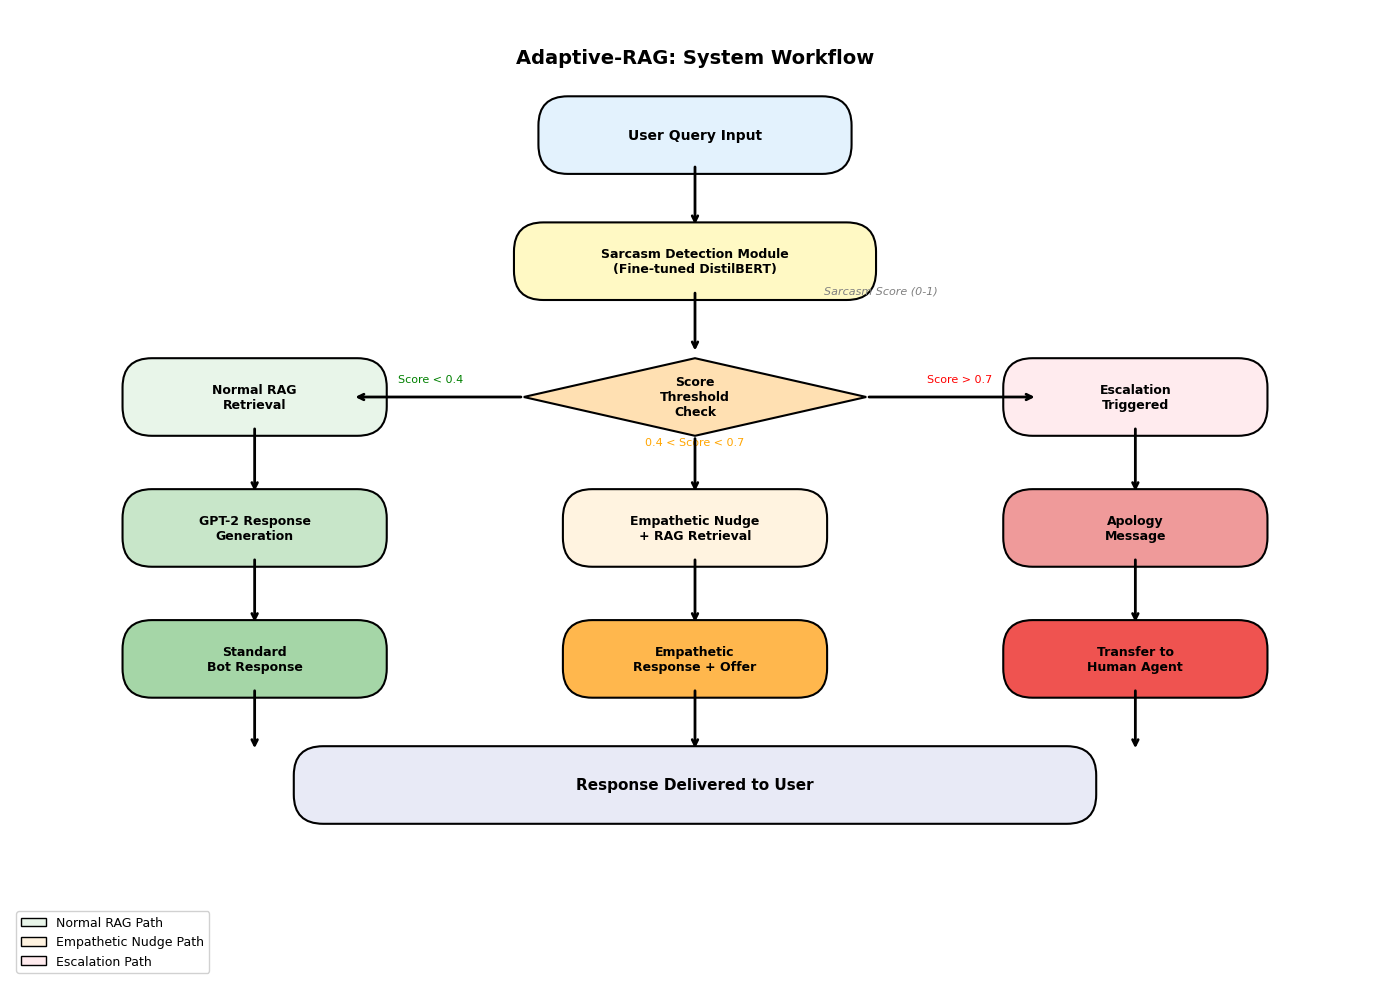

✅ Workflow Diagram save হয়েছে!


In [ ]:
# ======================================
# Workflow Diagram
# ======================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

# -----------------------------------------------
# Helper Functions
# -----------------------------------------------
def draw_box(ax, x, y, w, h, text, color, fontsize=10, radius=0.3):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f"round,pad=0.1,rounding_size={radius}",
        facecolor=color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold",
            wrap=True, multialignment="center")

def draw_arrow(ax, x1, y1, x2, y2, color="black"):
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=2.0
        )
    )

def draw_diamond(ax, x, y, w, h, text, color):
    diamond = plt.Polygon(
        [[x, y+h/2], [x+w/2, y], [x, y-h/2], [x-w/2, y]],
        facecolor=color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(diamond)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=9, fontweight="bold",
            multialignment="center")

# -----------------------------------------------
# Title
# -----------------------------------------------
ax.text(7, 9.5, "Adaptive-RAG: System Workflow",
        ha="center", va="center",
        fontsize=14, fontweight="bold")

# -----------------------------------------------
# Step 1 — User Input
# -----------------------------------------------
draw_box(ax, 7, 8.7, 3, 0.6,
         "User Query Input",
         "#E3F2FD", fontsize=10)

draw_arrow(ax, 7, 8.4, 7, 7.75)

# -----------------------------------------------
# Step 2 — Sarcasm Detection
# -----------------------------------------------
draw_box(ax, 7, 7.4, 3.5, 0.6,
         "Sarcasm Detection Module\n(Fine-tuned DistilBERT)",
         "#FFF9C4", fontsize=9)

# Score label
ax.text(8.9, 7.1, "Sarcasm Score (0-1)",
        ha="center", va="center",
        fontsize=8, color="gray", style="italic")

draw_arrow(ax, 7, 7.1, 7, 6.45)

# -----------------------------------------------
# Step 3 — Decision Diamond
# -----------------------------------------------
draw_diamond(ax, 7, 6.0, 3.5, 0.8,
             "Score\nThreshold\nCheck",
             "#FFE0B2")

# -----------------------------------------------
# Three Paths
# -----------------------------------------------

# Path 1 — NORMAL RAG (Score < 0.4)
draw_arrow(ax, 5.25, 6.0, 3.5, 6.0)
ax.text(4.3, 6.15, "Score < 0.4",
        ha="center", fontsize=8, color="green")
draw_box(ax, 2.5, 6.0, 2.5, 0.6,
         "Normal RAG\nRetrieval",
         "#E8F5E9", fontsize=9)
draw_arrow(ax, 2.5, 5.7, 2.5, 5.0)
draw_box(ax, 2.5, 4.65, 2.5, 0.6,
         "GPT-2 Response\nGeneration",
         "#C8E6C9", fontsize=9)
draw_arrow(ax, 2.5, 4.35, 2.5, 3.65)
draw_box(ax, 2.5, 3.3, 2.5, 0.6,
         "Standard\nBot Response",
         "#A5D6A7", fontsize=9)

# Path 2 — EMPATHETIC NUDGE (0.4 < Score < 0.7)
ax.text(7, 5.5, "0.4 < Score < 0.7",
        ha="center", fontsize=8, color="orange")
draw_arrow(ax, 7, 5.6, 7, 5.0)
draw_box(ax, 7, 4.65, 2.5, 0.6,
         "Empathetic Nudge\n+ RAG Retrieval",
         "#FFF3E0", fontsize=9)
draw_arrow(ax, 7, 4.35, 7, 3.65)
draw_box(ax, 7, 3.3, 2.5, 0.6,
         "Empathetic\nResponse + Offer",
         "#FFB74D", fontsize=9)

# Path 3 — ESCALATION (Score > 0.7)
draw_arrow(ax, 8.75, 6.0, 10.5, 6.0)
ax.text(9.7, 6.15, "Score > 0.7",
        ha="center", fontsize=8, color="red")
draw_box(ax, 11.5, 6.0, 2.5, 0.6,
         "Escalation\nTriggered",
         "#FFEBEE", fontsize=9)
draw_arrow(ax, 11.5, 5.7, 11.5, 5.0)
draw_box(ax, 11.5, 4.65, 2.5, 0.6,
         "Apology\nMessage",
         "#EF9A9A", fontsize=9)
draw_arrow(ax, 11.5, 4.35, 11.5, 3.65)
draw_box(ax, 11.5, 3.3, 2.5, 0.6,
         "Transfer to\nHuman Agent",
         "#EF5350", fontsize=9)

# -----------------------------------------------
# Final Output — all paths merge
# -----------------------------------------------
draw_arrow(ax, 2.5, 3.0, 2.5, 2.35)
draw_arrow(ax, 7, 3.0, 7, 2.35)
draw_arrow(ax, 11.5, 3.0, 11.5, 2.35)

draw_box(ax, 7, 2.0, 8, 0.6,
         "Response Delivered to User",
         "#E8EAF6", fontsize=11)

# -----------------------------------------------
# Legend
# -----------------------------------------------
legend_elements = [
    mpatches.Patch(facecolor="#E8F5E9", edgecolor="black",
                   label="Normal RAG Path"),
    mpatches.Patch(facecolor="#FFF3E0", edgecolor="black",
                   label="Empathetic Nudge Path"),
    mpatches.Patch(facecolor="#FFEBEE", edgecolor="black",
                   label="Escalation Path"),
]
ax.legend(handles=legend_elements,
          loc="lower left", fontsize=9,
          framealpha=0.9)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/workflow_diagram.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Workflow Diagram save হয়েছে!")

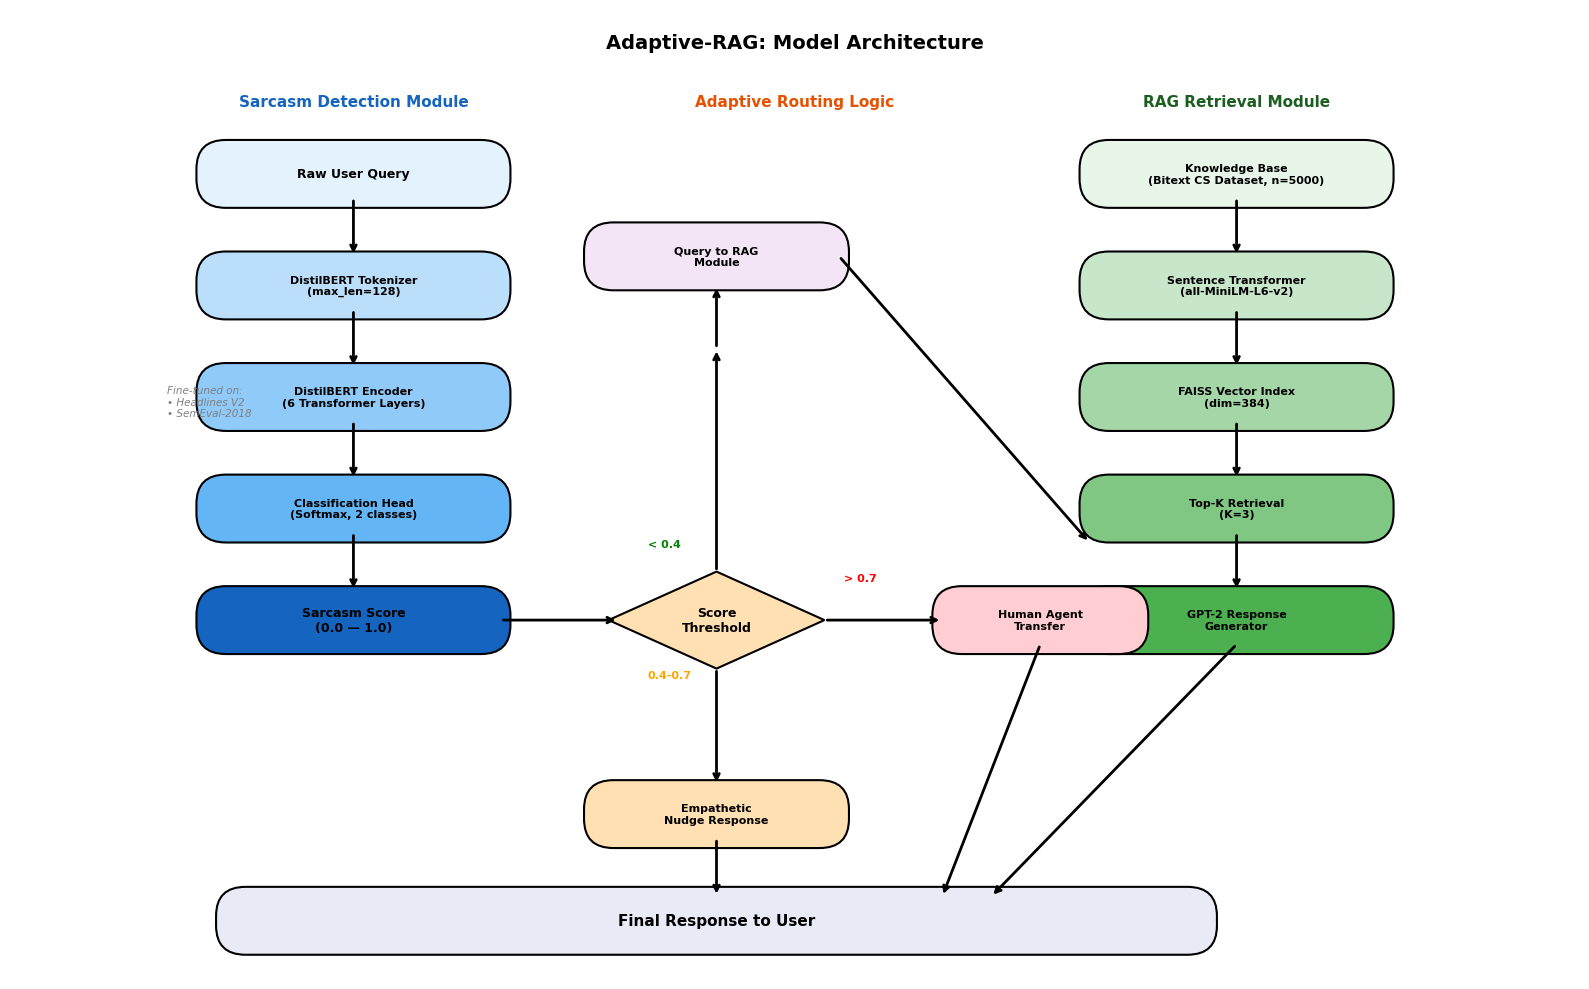

✅ Model Architecture save হয়েছে!


In [ ]:
# ======================================
# Model Architecture Diagram
# ======================================
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

ax.text(8, 9.6, "Adaptive-RAG: Model Architecture",
        ha="center", fontsize=14, fontweight="bold")

# -----------------------------------------------
# Left Side — Sarcasm Detection Module
# -----------------------------------------------
ax.text(3.5, 9.0, "Sarcasm Detection Module",
        ha="center", fontsize=11,
        fontweight="bold", color="#1565C0")

# Input
draw_box(ax, 3.5, 8.3, 3, 0.5,
         "Raw User Query", "#E3F2FD", fontsize=9)
draw_arrow(ax, 3.5, 8.05, 3.5, 7.45)

# Tokenizer
draw_box(ax, 3.5, 7.15, 3, 0.5,
         "DistilBERT Tokenizer\n(max_len=128)",
         "#BBDEFB", fontsize=8)
draw_arrow(ax, 3.5, 6.9, 3.5, 6.3)

# DistilBERT
draw_box(ax, 3.5, 6.0, 3, 0.5,
         "DistilBERT Encoder\n(6 Transformer Layers)",
         "#90CAF9", fontsize=8)
draw_arrow(ax, 3.5, 5.75, 3.5, 5.15)

# Fine-tuned on
ax.text(1.6, 5.8, "Fine-tuned on:\n• Headlines V2\n• SemEval-2018",
        ha="left", fontsize=7.5,
        color="gray", style="italic")

# Classifier
draw_box(ax, 3.5, 4.85, 3, 0.5,
         "Classification Head\n(Softmax, 2 classes)",
         "#64B5F6", fontsize=8)
draw_arrow(ax, 3.5, 4.6, 3.5, 4.0)

# Score output
draw_box(ax, 3.5, 3.7, 3, 0.5,
         "Sarcasm Score\n(0.0 — 1.0)",
         "#1565C0", fontsize=9)

# -----------------------------------------------
# Middle — Decision Logic
# -----------------------------------------------
ax.text(8, 9.0, "Adaptive Routing Logic",
        ha="center", fontsize=11,
        fontweight="bold", color="#E65100")

draw_arrow(ax, 5.0, 3.7, 6.2, 3.7)

draw_diamond(ax, 7.2, 3.7, 2.2, 1.0,
             "Score\nThreshold",
             "#FFE0B2")

# Labels
ax.text(6.5, 4.45, "< 0.4", fontsize=8,
        color="green", fontweight="bold")
ax.text(6.5, 3.1, "0.4-0.7", fontsize=8,
        color="orange", fontweight="bold")
ax.text(8.5, 4.1, "> 0.7", fontsize=8,
        color="red", fontweight="bold")

# Arrows from diamond
draw_arrow(ax, 7.2, 4.2, 7.2, 6.5)   # up — normal
draw_arrow(ax, 7.2, 3.2, 7.2, 2.0)   # down — nudge
draw_arrow(ax, 8.3, 3.7, 9.5, 3.7)   # right — escalation

# -----------------------------------------------
# Right Side — RAG Module
# -----------------------------------------------
ax.text(12.5, 9.0, "RAG Retrieval Module",
        ha="center", fontsize=11,
        fontweight="bold", color="#1B5E20")

# Knowledge Base
draw_box(ax, 12.5, 8.3, 3, 0.5,
         "Knowledge Base\n(Bitext CS Dataset, n=5000)",
         "#E8F5E9", fontsize=8)
draw_arrow(ax, 12.5, 8.05, 12.5, 7.45)

# Sentence Transformer
draw_box(ax, 12.5, 7.15, 3, 0.5,
         "Sentence Transformer\n(all-MiniLM-L6-v2)",
         "#C8E6C9", fontsize=8)
draw_arrow(ax, 12.5, 6.9, 12.5, 6.3)

# FAISS Index
draw_box(ax, 12.5, 6.0, 3, 0.5,
         "FAISS Vector Index\n(dim=384)",
         "#A5D6A7", fontsize=8)
draw_arrow(ax, 12.5, 5.75, 12.5, 5.15)

# Top-k retrieval
draw_box(ax, 12.5, 4.85, 3, 0.5,
         "Top-K Retrieval\n(K=3)",
         "#81C784", fontsize=8)
draw_arrow(ax, 12.5, 4.6, 12.5, 4.0)

# GPT-2 Generator
draw_box(ax, 12.5, 3.7, 3, 0.5,
         "GPT-2 Response\nGenerator",
         "#4CAF50", fontsize=8)

# -----------------------------------------------
# Normal RAG path — connect
# -----------------------------------------------
draw_arrow(ax, 7.2, 6.5, 7.2, 7.15)
draw_box(ax, 7.2, 7.45, 2.5, 0.5,
         "Query to RAG\nModule",
         "#F3E5F5", fontsize=8)
draw_arrow(ax, 8.45, 7.45, 11.0, 4.5)

# -----------------------------------------------
# Escalation path
# -----------------------------------------------
draw_box(ax, 10.5, 3.7, 2, 0.5,
         "Human Agent\nTransfer",
         "#FFCDD2", fontsize=8)

# -----------------------------------------------
# Nudge path
# -----------------------------------------------
draw_box(ax, 7.2, 1.7, 2.5, 0.5,
         "Empathetic\nNudge Response",
         "#FFE0B2", fontsize=8)

# -----------------------------------------------
# Final Output
# -----------------------------------------------
draw_box(ax, 7.2, 0.6, 10, 0.5,
         "Final Response to User",
         "#E8EAF6", fontsize=11)

draw_arrow(ax, 7.2, 1.45, 7.2, 0.85)
draw_arrow(ax, 12.5, 3.45, 10.0, 0.85)
draw_arrow(ax, 10.5, 3.45, 9.5, 0.85)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/model_architecture.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Model Architecture save হয়েছে!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/workflow_diagram.png'

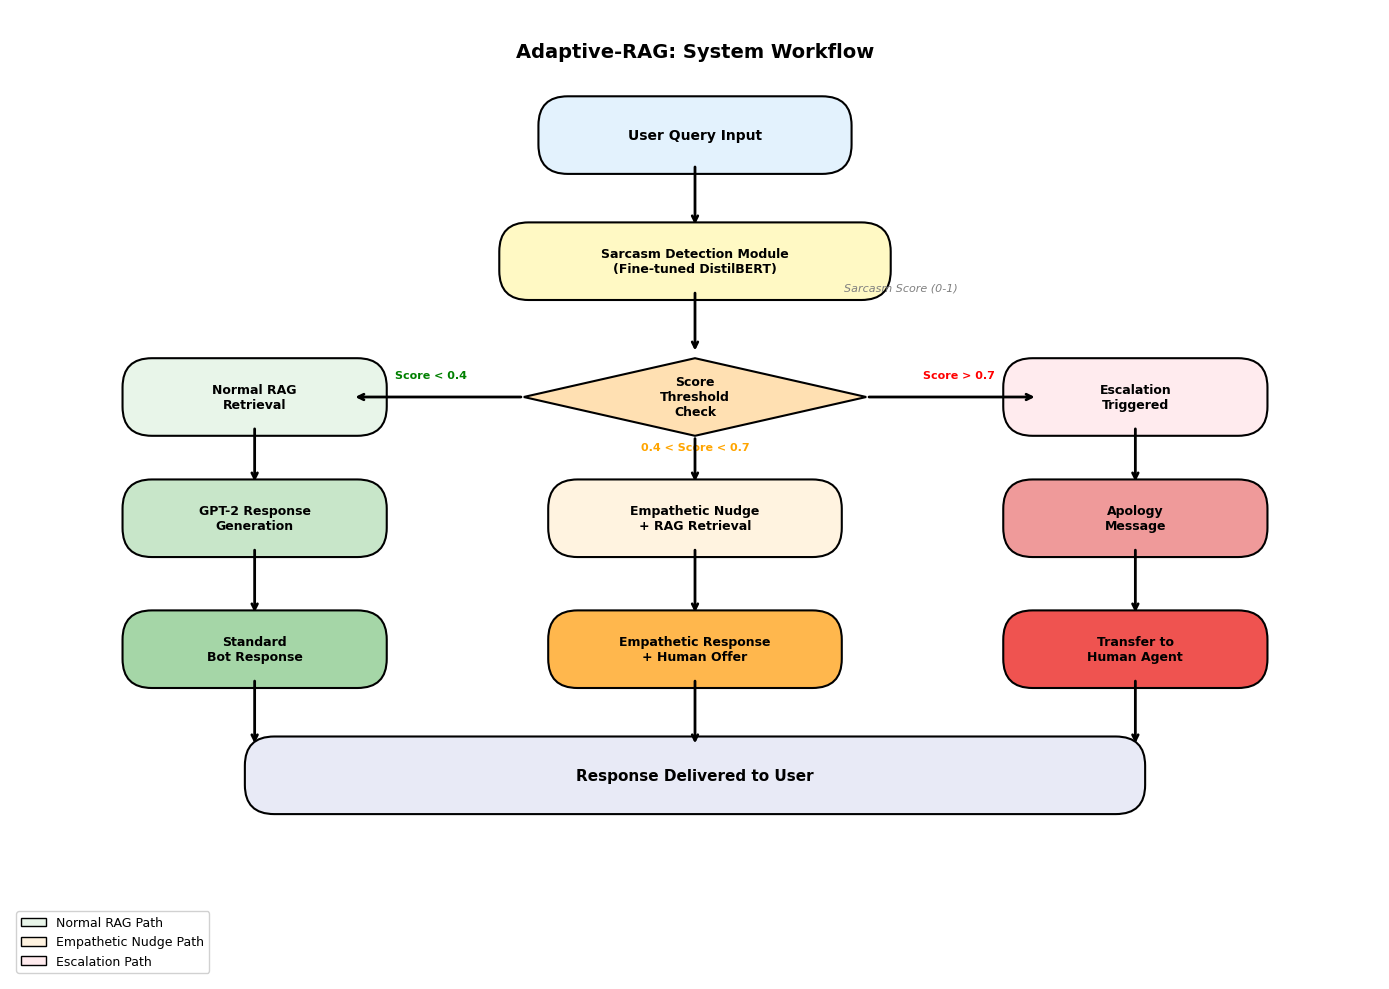

In [ ]:
# ======================================
# Workflow Diagram
# ======================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

def draw_box(ax, x, y, w, h, text, color, fontsize=10, radius=0.3):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f"round,pad=0.1,rounding_size={radius}",
        facecolor=color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold",
            multialignment="center")

def draw_arrow(ax, x1, y1, x2, y2, color="black"):
    ax.annotate("",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color=color, lw=2.0)
    )

def draw_diamond(ax, x, y, w, h, text, color):
    diamond = plt.Polygon(
        [[x, y+h/2], [x+w/2, y], [x, y-h/2], [x-w/2, y]],
        facecolor=color, edgecolor="black", linewidth=1.5
    )
    ax.add_patch(diamond)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=9, fontweight="bold",
            multialignment="center")

# Title
ax.text(7, 9.5, "Adaptive-RAG: System Workflow",
        ha="center", fontsize=14, fontweight="bold")

# Step 1
draw_box(ax, 7, 8.7, 3, 0.6, "User Query Input",
         "#E3F2FD", fontsize=10)
draw_arrow(ax, 7, 8.4, 7, 7.75)

# Step 2
draw_box(ax, 7, 7.4, 3.8, 0.6,
         "Sarcasm Detection Module\n(Fine-tuned DistilBERT)",
         "#FFF9C4", fontsize=9)
ax.text(9.1, 7.1, "Sarcasm Score (0-1)",
        ha="center", fontsize=8, color="gray", style="italic")
draw_arrow(ax, 7, 7.1, 7, 6.45)

# Decision Diamond
draw_diamond(ax, 7, 6.0, 3.5, 0.8,
             "Score\nThreshold\nCheck", "#FFE0B2")

# Path 1 — Normal RAG
draw_arrow(ax, 5.25, 6.0, 3.5, 6.0)
ax.text(4.3, 6.2, "Score < 0.4",
        ha="center", fontsize=8, color="green", fontweight="bold")
draw_box(ax, 2.5, 6.0, 2.5, 0.6,
         "Normal RAG\nRetrieval", "#E8F5E9", fontsize=9)
draw_arrow(ax, 2.5, 5.7, 2.5, 5.1)
draw_box(ax, 2.5, 4.75, 2.5, 0.6,
         "GPT-2 Response\nGeneration", "#C8E6C9", fontsize=9)
draw_arrow(ax, 2.5, 4.45, 2.5, 3.75)
draw_box(ax, 2.5, 3.4, 2.5, 0.6,
         "Standard\nBot Response", "#A5D6A7", fontsize=9)

# Path 2 — Empathetic Nudge
ax.text(7, 5.45, "0.4 < Score < 0.7",
        ha="center", fontsize=8, color="orange", fontweight="bold")
draw_arrow(ax, 7, 5.6, 7, 5.1)
draw_box(ax, 7, 4.75, 2.8, 0.6,
         "Empathetic Nudge\n+ RAG Retrieval", "#FFF3E0", fontsize=9)
draw_arrow(ax, 7, 4.45, 7, 3.75)
draw_box(ax, 7, 3.4, 2.8, 0.6,
         "Empathetic Response\n+ Human Offer", "#FFB74D", fontsize=9)

# Path 3 — Escalation
draw_arrow(ax, 8.75, 6.0, 10.5, 6.0)
ax.text(9.7, 6.2, "Score > 0.7",
        ha="center", fontsize=8, color="red", fontweight="bold")
draw_box(ax, 11.5, 6.0, 2.5, 0.6,
         "Escalation\nTriggered", "#FFEBEE", fontsize=9)
draw_arrow(ax, 11.5, 5.7, 11.5, 5.1)
draw_box(ax, 11.5, 4.75, 2.5, 0.6,
         "Apology\nMessage", "#EF9A9A", fontsize=9)
draw_arrow(ax, 11.5, 4.45, 11.5, 3.75)
draw_box(ax, 11.5, 3.4, 2.5, 0.6,
         "Transfer to\nHuman Agent", "#EF5350", fontsize=9)

# Final merge
draw_arrow(ax, 2.5, 3.1, 2.5, 2.4)
draw_arrow(ax, 7, 3.1, 7, 2.4)
draw_arrow(ax, 11.5, 3.1, 11.5, 2.4)
draw_box(ax, 7, 2.1, 9, 0.6,
         "Response Delivered to User",
         "#E8EAF6", fontsize=11)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#E8F5E9", edgecolor="black",
                   label="Normal RAG Path"),
    mpatches.Patch(facecolor="#FFF3E0", edgecolor="black",
                   label="Empathetic Nudge Path"),
    mpatches.Patch(facecolor="#FFEBEE", edgecolor="black",
                   label="Escalation Path"),
]
ax.legend(handles=legend_elements,
          loc="lower left", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/workflow_diagram.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Workflow Diagram save হয়েছে!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/model_architecture.png'

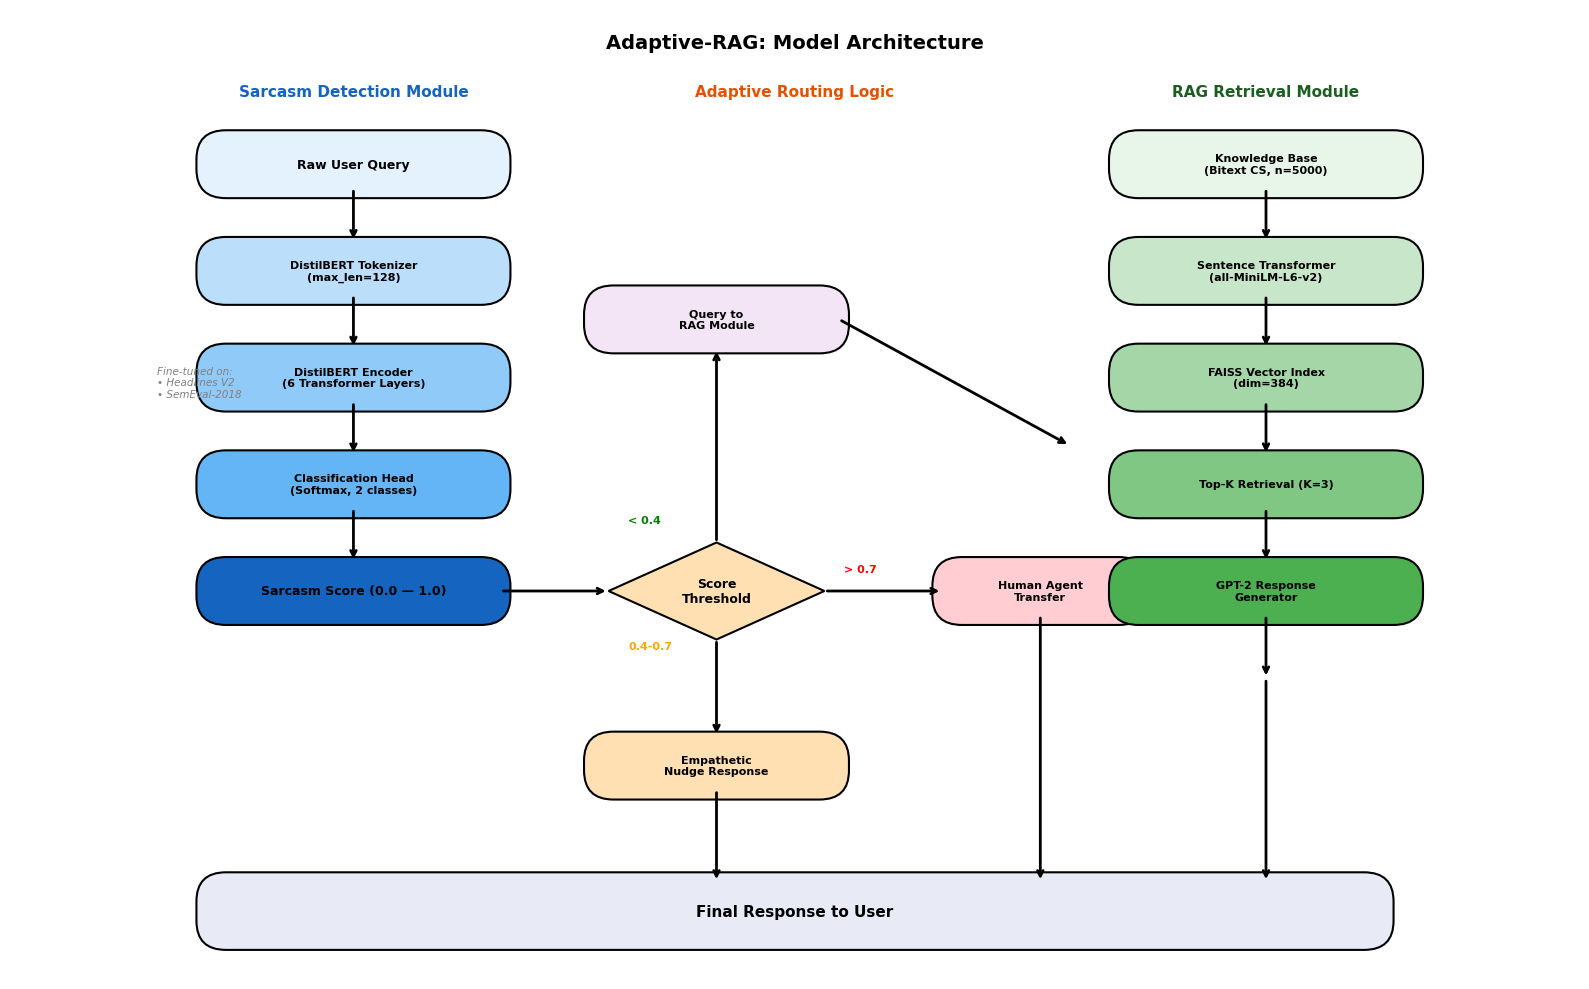

In [ ]:
# ======================================
# Model Architecture Diagram
# ======================================
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

ax.text(8, 9.6, "Adaptive-RAG: Model Architecture",
        ha="center", fontsize=14, fontweight="bold")

# -----------------------------------------------
# Left — Sarcasm Detection Module
# -----------------------------------------------
ax.text(3.5, 9.1, "Sarcasm Detection Module",
        ha="center", fontsize=11,
        fontweight="bold", color="#1565C0")

draw_box(ax, 3.5, 8.4, 3, 0.5,
         "Raw User Query", "#E3F2FD", fontsize=9)
draw_arrow(ax, 3.5, 8.15, 3.5, 7.6)

draw_box(ax, 3.5, 7.3, 3, 0.5,
         "DistilBERT Tokenizer\n(max_len=128)",
         "#BBDEFB", fontsize=8)
draw_arrow(ax, 3.5, 7.05, 3.5, 6.5)

draw_box(ax, 3.5, 6.2, 3, 0.5,
         "DistilBERT Encoder\n(6 Transformer Layers)",
         "#90CAF9", fontsize=8)
ax.text(1.5, 6.0, "Fine-tuned on:\n• Headlines V2\n• SemEval-2018",
        ha="left", fontsize=7.5, color="gray", style="italic")
draw_arrow(ax, 3.5, 5.95, 3.5, 5.4)

draw_box(ax, 3.5, 5.1, 3, 0.5,
         "Classification Head\n(Softmax, 2 classes)",
         "#64B5F6", fontsize=8)
draw_arrow(ax, 3.5, 4.85, 3.5, 4.3)

draw_box(ax, 3.5, 4.0, 3, 0.5,
         "Sarcasm Score (0.0 — 1.0)",
         "#1565C0", fontsize=9)

# -----------------------------------------------
# Middle — Decision Logic
# -----------------------------------------------
ax.text(8, 9.1, "Adaptive Routing Logic",
        ha="center", fontsize=11,
        fontweight="bold", color="#E65100")

draw_arrow(ax, 5.0, 4.0, 6.1, 4.0)
draw_diamond(ax, 7.2, 4.0, 2.2, 1.0,
             "Score\nThreshold", "#FFE0B2")

ax.text(6.3, 4.7, "< 0.4", fontsize=8,
        color="green", fontweight="bold")
ax.text(6.3, 3.4, "0.4-0.7", fontsize=8,
        color="orange", fontweight="bold")
ax.text(8.5, 4.2, "> 0.7", fontsize=8,
        color="red", fontweight="bold")

# Normal path — up
draw_arrow(ax, 7.2, 4.5, 7.2, 6.5)
draw_box(ax, 7.2, 6.8, 2.5, 0.5,
         "Query to\nRAG Module", "#F3E5F5", fontsize=8)
draw_arrow(ax, 8.45, 6.8, 10.8, 5.5)

# Nudge path — down
draw_arrow(ax, 7.2, 3.5, 7.2, 2.5)
draw_box(ax, 7.2, 2.2, 2.5, 0.5,
         "Empathetic\nNudge Response", "#FFE0B2", fontsize=8)

# Escalation path — right
draw_arrow(ax, 8.3, 4.0, 9.5, 4.0)
draw_box(ax, 10.5, 4.0, 2, 0.5,
         "Human Agent\nTransfer", "#FFCDD2", fontsize=8)

# -----------------------------------------------
# Right — RAG Module
# -----------------------------------------------
ax.text(12.8, 9.1, "RAG Retrieval Module",
        ha="center", fontsize=11,
        fontweight="bold", color="#1B5E20")

draw_box(ax, 12.8, 8.4, 3, 0.5,
         "Knowledge Base\n(Bitext CS, n=5000)",
         "#E8F5E9", fontsize=8)
draw_arrow(ax, 12.8, 8.15, 12.8, 7.6)

draw_box(ax, 12.8, 7.3, 3, 0.5,
         "Sentence Transformer\n(all-MiniLM-L6-v2)",
         "#C8E6C9", fontsize=8)
draw_arrow(ax, 12.8, 7.05, 12.8, 6.5)

draw_box(ax, 12.8, 6.2, 3, 0.5,
         "FAISS Vector Index\n(dim=384)",
         "#A5D6A7", fontsize=8)
draw_arrow(ax, 12.8, 5.95, 12.8, 5.4)

draw_box(ax, 12.8, 5.1, 3, 0.5,
         "Top-K Retrieval (K=3)",
         "#81C784", fontsize=8)
draw_arrow(ax, 12.8, 4.85, 12.8, 4.3)

draw_box(ax, 12.8, 4.0, 3, 0.5,
         "GPT-2 Response\nGenerator",
         "#4CAF50", fontsize=8)
draw_arrow(ax, 12.8, 3.75, 12.8, 3.1)

# -----------------------------------------------
# Final Output
# -----------------------------------------------
draw_box(ax, 8, 0.7, 12, 0.6,
         "Final Response to User",
         "#E8EAF6", fontsize=11)

draw_arrow(ax, 7.2, 1.95, 7.2, 1.0)
draw_arrow(ax, 10.5, 3.75, 10.5, 1.0)
draw_arrow(ax, 12.8, 3.1, 12.8, 1.0)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/model_architecture.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Model Architecture save হয়েছে!")

In [1]:
# ======================================
# Adaptive-RAG Chat Interface
# ======================================
!pip install gradio -q
print("✅ Install শেষ!")

✅ Install শেষ!


In [3]:
!pip install gradio transformers sentence-transformers faiss-cpu torch -q
print("✅ Install শেষ!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 38.6 MB/s eta 0:00:00
✅ Install শেষ!


In [4]:
import gradio as gr
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    GPT2LMHeadModel,
    GPT2Tokenizer
)
from sentence_transformers import SentenceTransformer
import faiss
import pickle
import numpy as np

# ======================================
# Model + Data Load করো
# ======================================
from google.colab import drive
drive.mount('/content/drive')

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Sarcasm Model
tokenizer = DistilBertTokenizer.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
)
model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/sarcasm_model"
).to(device)

# GPT-2
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_model.config.eos_token_id

# RAG
cs_documents = pickle.load(
    open("/content/drive/MyDrive/cs_documents.pkl", "rb")
)
cs_metadata = pickle.load(
    open("/content/drive/MyDrive/cs_metadata.pkl", "rb")
)
cs_index = faiss.read_index(
    "/content/drive/MyDrive/cs_faiss.index"
)
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("✅ সব লোড হয়েছে!")

Mounted at /content/drive


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ সব লোড হয়েছে!


In [5]:
# ======================================
# Chat Function
# ======================================
def retrieve(query, top_k=1):
    q_emb = embedder.encode([query])
    _, indices = cs_index.search(
        np.array(q_emb), top_k
    )
    return cs_metadata[indices[0][0]]["response"]

def generate(query, doc):
    prompt = (
        f"Customer query: {query}\n"
        f"Relevant information: {doc[:200]}\n"
        f"Customer service response:"
    )
    inputs = gpt2_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=400
    ).to(device)
    with torch.no_grad():
        output = gpt2_model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=80,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2,
            do_sample=False,
            pad_token_id=gpt2_tokenizer.eos_token_id
        )
    return gpt2_tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

def chat(user_message, history):
    # Sarcasm Score
    inputs = tokenizer(
        user_message,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        score = torch.softmax(
            outputs.logits, dim=1
        )[0][1].item()

    # Path Decision
    if score > 0.7:
        path = "🔴 ESCALATION"
        response = (
            "I sincerely apologize for your experience. "
            "I understand your frustration and I am "
            "connecting you with a human agent who will "
            "resolve this immediately. Please hold on."
        )
    elif score > 0.4:
        path = "🟡 EMPATHETIC NUDGE"
        doc = retrieve(user_message)
        generated = generate(user_message, doc)
        response = (
            f"I understand this may be frustrating. "
            f"{generated} "
            f"Would you like me to connect you with "
            f"a human agent instead?"
        )
    else:
        path = "🟢 NORMAL RAG"
        doc = retrieve(user_message)
        response = generate(user_message, doc)

    # Score info যোগ করো
    info = (
        f"\n\n---\n"
        f"🎭 Sarcasm Score: {score:.3f} | "
        f"Path: {path}"
    )

    return response + info

# ======================================
# Gradio Interface
# ======================================
with gr.Blocks(
    title="Adaptive-RAG Customer Support",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown("""
    # 🤖 Adaptive-RAG Customer Support Chatbot
    ### Sarcasm-Aware | Intelligent Escalation | SME Support
    ---
    """)

    gr.Markdown("""
    **How it works:**
    - 🟢 Normal query → Standard bot response
    - 🟡 Frustrated query → Empathetic response + human offer
    - 🔴 Sarcastic/angry query → Human agent escalation
    """)

    chatbot = gr.Chatbot(
        height=450,
        label="Chat",
        bubble_full_width=False
    )

    with gr.Row():
        msg = gr.Textbox(
            placeholder="Type your message here...",
            label="Your Message",
            scale=4
        )
        send = gr.Button("Send 📤", scale=1)

    with gr.Row():
        clear = gr.Button("Clear Chat 🗑️")

    gr.Examples(
        examples=[
            "How do I track my order?",
            "I need help with my refund please.",
            "Oh fantastic, my package has been lost "
            "for 3 weeks, truly amazing service!",
            "Can you help me reset my password?",
            "Wow great job charging me twice, "
            "really impressive billing system!",
            "I am quite unhappy with the "
            "refund process.",
        ],
        inputs=msg,
        label="Try these examples:"
    )

    def respond(message, chat_history):
        if not message.strip():
            return "", chat_history
        bot_response = chat(message, chat_history)
        chat_history.append((message, bot_response))
        return "", chat_history

    send.click(
        respond,
        inputs=[msg, chatbot],
        outputs=[msg, chatbot]
    )
    msg.submit(
        respond,
        inputs=[msg, chatbot],
        outputs=[msg, chatbot]
    )
    clear.click(
        lambda: ([], ""),
        outputs=[chatbot, msg]
    )

demo.launch(
    share=True,
    debug=False
)

/tmp/ipykernel_882/3495101886.py:90: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_882/3495101886.py:108: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_882/3495101886.py:108: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chatbot = gr.Chatbot(
/tmp/ipykernel_882/3495101886.py:108: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags 

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d87a3e272c08e476c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
# ======================================
# Fixed Chat Function
# RAG document directly return করবে
# ======================================
def retrieve(query, top_k=1):
    q_emb = embedder.encode([query])
    _, indices = cs_index.search(
        np.array(q_emb), top_k
    )
    return cs_metadata[indices[0][0]]["response"]

def chat(user_message, history):
    # Sarcasm Score
    inputs = tokenizer(
        user_message,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        score = torch.softmax(
            outputs.logits, dim=1
        )[0][1].item()

    # Path Decision
    if score > 0.7:
        path = "🔴 ESCALATION"
        response = (
            "I sincerely apologize for your experience. "
            "I understand your frustration and I am "
            "connecting you with a human agent who will "
            "resolve this immediately. Please hold on."
        )

    elif score > 0.4:
        path = "🟡 EMPATHETIC NUDGE"
        # ✅ Fix — directly retrieved response
        retrieved = retrieve(user_message)
        response = (
            f"I understand this may be frustrating. "
            f"{retrieved} "
            f"\n\nWould you like me to connect you "
            f"with a human agent instead?"
        )

    else:
        path = "🟢 NORMAL RAG"
        # ✅ Fix — directly retrieved response
        response = retrieve(user_message)

    # Score info
    info = (
        f"\n\n---\n"
        f"Sarcasm Score: {score:.3f} | "
        f"Path: {path}"
    )

    return response + info

# ======================================
# Gradio Interface — same as before
# ======================================
with gr.Blocks(
    title="Adaptive-RAG Customer Support",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown("""
    # 🤖 Adaptive-RAG Customer Support Chatbot
    ### Sarcasm-Aware | Intelligent Escalation | SME Support
    ---
    """)

    gr.Markdown("""
    **How it works:**
    - 🟢 Normal query → Standard bot response
    - 🟡 Frustrated query → Empathetic response + human offer
    - 🔴 Sarcastic/angry query → Human agent escalation
    """)

    chatbot = gr.Chatbot(
        height=450,
        label="Chat",
        bubble_full_width=False
    )

    with gr.Row():
        msg = gr.Textbox(
            placeholder="Type your message here...",
            label="Your Message",
            scale=4
        )
        send = gr.Button("Send 📤", scale=1)

    with gr.Row():
        clear = gr.Button("Clear Chat 🗑️")

    gr.Examples(
        examples=[
            "How do I cancel my subscription?",
            "How do I track my order?",
            "I need help with my refund please.",
            "Oh fantastic, my package has been "
            "lost for 3 weeks, truly amazing service!",
            "Can you help me reset my password?",
            "Wow great job charging me twice, "
            "really impressive billing system!",
            "I am quite unhappy with the refund process.",
        ],
        inputs=msg,
        label="Try these examples:"
    )

    def respond(message, chat_history):
        if not message.strip():
            return "", chat_history
        bot_response = chat(message, chat_history)
        chat_history.append((message, bot_response))
        return "", chat_history

    send.click(
        respond,
        inputs=[msg, chatbot],
        outputs=[msg, chatbot]
    )
    msg.submit(
        respond,
        inputs=[msg, chatbot],
        outputs=[msg, chatbot]
    )
    clear.click(
        lambda: ([], ""),
        outputs=[chatbot, msg]
    )

demo.launch(
    share=True,
    debug=False
)

/tmp/ipykernel_882/2377141502.py:65: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_882/2377141502.py:83: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_882/2377141502.py:83: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chatbot = gr.Chatbot(
/tmp/ipykernel_882/2377141502.py:83: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in 

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6da367294918aa3a78.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
